In [205]:
import warnings

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import pandas as pd

In [206]:
import firebirdsql.wireprotocol as wp
from firebirdsql.consts import charset_map

_orig = wp.WireProtocol.bytes_to_str


def _safe_decode(self, b):
    charset = charset_map.get(self.charset, self.charset)
    return b.decode(charset, errors="replace")


wp.WireProtocol.bytes_to_str = _safe_decode

In [207]:
import firebirdsql

DATABASES = {
    # HULTER (23 t/m 25)
    "23_hulter": "/firebird/data/HULTER_23 - kopie.GDB",
    "24_hulter": "/firebird/data/HULTER_24 - kopie.GDB",
    "25_hulter": "/firebird/data/HULTER_25 - kopie.GDB",
    # KUIJPERS (24 t/m 26)
    "24_kuijpers": "/firebird/data/HOOFD_24.GDB",
    "25_kuijpers": "/firebird/data/HOOFD_25.GDB",
    "26_kuijpers": "/firebird/data/HOOFD_26.GDB",
    # MELSE (Elk jaar vanaf 09 t/m 26)
    "09_melse": "/firebird/data/MELSE2009.GDB",
    **{f"{jaar}_melse": f"/firebird/data/MELSE20{jaar}.GDB" for jaar in range(10, 26)},
    # POEL (Elk jaar vanaf 14 t/m 26)
    **{f"{jaar}_poel": f"/firebird/data/POEL_20{jaar}.GDB" for jaar in range(14, 26)},
    # WESTRA (14 t/m 26)
    **{f"{jaar}_westra": f"/firebird/data/WESTRA_{jaar}.GDB" for jaar in range(14, 26)},
    # JENNISSEN (20 t/m 26)
    **{f"{jaar}_jennissen": f"/firebird/data/jennissen_{jaar}.GDB" for jaar in range(20, 26)},
    # DERKS (23 t/m 26)
    "23_derks": "/firebird/data/DERKS_23.GDB",
    "24_derks": "/firebird/data/DERKS_24.GDB",
    "25_derks": "/firebird/data/DERKS_25.GDB",
    # DIEPEN (21 t/m 26)
    **{f"{jaar}_diepen": f"/firebird/data/DIEPEN_{jaar}.GDB" for jaar in range(21, 26)},
}

connections = {
    naam: firebirdsql.connect(
        host="mac-mini-van-terra.local",
        port=3050,
        database=pad,
        user="SYSDBA",
        password="masterkey",
        charset="WIN1252",
    )
    for naam, pad in DATABASES.items()
}

print(f"{len(connections)} databases verbonden: {list(connections.keys())}")

61 databases verbonden: ['23_hulter', '24_hulter', '25_hulter', '24_kuijpers', '25_kuijpers', '26_kuijpers', '09_melse', '10_melse', '11_melse', '12_melse', '13_melse', '14_melse', '15_melse', '16_melse', '17_melse', '18_melse', '19_melse', '20_melse', '21_melse', '22_melse', '23_melse', '24_melse', '25_melse', '14_poel', '15_poel', '16_poel', '17_poel', '18_poel', '19_poel', '20_poel', '21_poel', '22_poel', '23_poel', '24_poel', '25_poel', '14_westra', '15_westra', '16_westra', '17_westra', '18_westra', '19_westra', '20_westra', '21_westra', '22_westra', '23_westra', '24_westra', '25_westra', '20_jennissen', '21_jennissen', '22_jennissen', '23_jennissen', '24_jennissen', '25_jennissen', '23_derks', '24_derks', '25_derks', '21_diepen', '22_diepen', '23_diepen', '24_diepen', '25_diepen']


In [208]:
def fetch_combined(table_name, columns="*"):
    """
    Haalt data op uit alle databases en combineert dit in één DataFrame.

    De kolom 'con' geeft aan uit welke database een rij afkomstig is.
    Exacte duplicaten (zelfde rij in meerdere databases) worden verwijderd.
    """
    frames = []
    for db_name, conn in connections.items():
        df = pd.read_sql(f"SELECT {columns} FROM {table_name}", conn)
        df["con"] = db_name
        frames.append(df)

    combined = pd.concat(frames, ignore_index=True)
    return combined.drop_duplicates()

In [209]:
query = """SELECT
    -- TABEL INFO
    t.RDB$RELATION_NAME                         AS tabel,
    f.RDB$FIELD_POSITION + 1                    AS kolom_volgorde,
    f.RDB$FIELD_NAME                            AS kolom,
    tp.RDB$TYPE_NAME                            AS datatype,
    fld.RDB$FIELD_LENGTH                        AS lengte,
    fld.RDB$FIELD_PRECISION                     AS precisie,
    fld.RDB$FIELD_SCALE                         AS schaal,
    f.RDB$NULL_FLAG                             AS not_null,

    -- PRIMARY KEY
    CASE WHEN pk.RDB$FIELD_NAME IS NOT NULL
         THEN 'JA' ELSE 'NEE' END               AS primary_key,

    -- UNIQUE
    CASE WHEN uq.RDB$FIELD_NAME IS NOT NULL
         THEN 'JA' ELSE 'NEE' END               AS unique_key,

    -- FOREIGN KEY (van deze kolom naar andere tabel)
    fk_to.RDB$RELATION_NAME                     AS fk_naar_tabel,
    fk_to_col.RDB$FIELD_NAME                    AS fk_naar_kolom

FROM
    RDB$RELATIONS t

    -- Kolommen
    JOIN RDB$RELATION_FIELDS f
        ON f.RDB$RELATION_NAME = t.RDB$RELATION_NAME

    -- Veld definities (type, lengte etc.)
    JOIN RDB$FIELDS fld
        ON fld.RDB$FIELD_NAME = f.RDB$FIELD_SOURCE

    -- Datatype naam
    LEFT JOIN RDB$TYPES tp
        ON tp.RDB$TYPE = fld.RDB$FIELD_TYPE
        AND tp.RDB$FIELD_NAME = 'RDB$FIELD_TYPE'

    -- Primary key check
    LEFT JOIN RDB$RELATION_CONSTRAINTS pk_rc
        ON pk_rc.RDB$RELATION_NAME = t.RDB$RELATION_NAME
        AND pk_rc.RDB$CONSTRAINT_TYPE = 'PRIMARY KEY'
    LEFT JOIN RDB$INDEX_SEGMENTS pk
        ON pk.RDB$INDEX_NAME = pk_rc.RDB$INDEX_NAME
        AND pk.RDB$FIELD_NAME = f.RDB$FIELD_NAME

    -- Unique key check
    LEFT JOIN RDB$RELATION_CONSTRAINTS uq_rc
        ON uq_rc.RDB$RELATION_NAME = t.RDB$RELATION_NAME
        AND uq_rc.RDB$CONSTRAINT_TYPE = 'UNIQUE'
    LEFT JOIN RDB$INDEX_SEGMENTS uq
        ON uq.RDB$INDEX_NAME = uq_rc.RDB$INDEX_NAME
        AND uq.RDB$FIELD_NAME = f.RDB$FIELD_NAME

    -- Foreign key van deze tabel/kolom
    LEFT JOIN RDB$RELATION_CONSTRAINTS fk_rc
        ON fk_rc.RDB$RELATION_NAME = t.RDB$RELATION_NAME
        AND fk_rc.RDB$CONSTRAINT_TYPE = 'FOREIGN KEY'
    LEFT JOIN RDB$INDEX_SEGMENTS fk_seg
        ON fk_seg.RDB$INDEX_NAME = fk_rc.RDB$INDEX_NAME
        AND fk_seg.RDB$FIELD_NAME = f.RDB$FIELD_NAME
    LEFT JOIN RDB$REF_CONSTRAINTS ref
        ON ref.RDB$CONSTRAINT_NAME = fk_rc.RDB$CONSTRAINT_NAME
    LEFT JOIN RDB$RELATION_CONSTRAINTS fk_to
        ON fk_to.RDB$CONSTRAINT_NAME = ref.RDB$CONST_NAME_UQ
    LEFT JOIN RDB$INDEX_SEGMENTS fk_to_col
        ON fk_to_col.RDB$INDEX_NAME = fk_to.RDB$INDEX_NAME
        AND fk_to_col.RDB$FIELD_POSITION = fk_seg.RDB$FIELD_POSITION

WHERE
    t.RDB$SYSTEM_FLAG = 0       -- geen systeem-tabellen
    AND t.RDB$VIEW_BLR IS NULL  -- geen views

ORDER BY
    t.RDB$RELATION_NAME,
    f.RDB$FIELD_POSITION;"""

In [210]:
schema_info = pd.read_sql(query, connections["23_hulter"])

In [211]:
schema_info.to_csv("schema_info.csv", index=False)

## Verwijder epoch-datumwaarden 

In [212]:
URENVERANTW = fetch_combined("TB_URENVERANTWOORDING")

In [213]:
URENVERANTW.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1698079 entries, 0 to 1698078
Data columns (total 29 columns):
 #   Column                      Dtype  
---  ------                      -----  
 0   URENVERANTW_ID              object 
 1   URENVERANTW_DATUM           object 
 2   URENVERANTW_PROJID          float64
 3   URENVERANTW_RELATIEID       float64
 4   URENVERANTW_TIJDSOORT       object 
 5   URENVERANTW_AANTAL          float64
 6   URENVERANTW_MACHID          float64
 7   URENVERANTW_MEDID           object 
 8   URENVERANTW_ORDERID         float64
 9   URENVERANTW_ORDDAID         float64
 10  URENVERANTW_ORDMEDID        float64
 11  URENVERANTW_TIJD            object 
 12  URENVERANTW_ORDRG_ID        float64
 13  URENVERANTW_GROEPSID        float64
 14  URENVERANTW_CONTROLE        float64
 15  URENVERANTW_WEEKNR          object 
 16  URENVERANTW_JAAR            object 
 17  URENVERANTW_STARTTIJD       object 
 18  URENVERANTW_STOPTIJD        object 
 19  URENVERANTW_ONDERBREK

In [214]:
URENVERANTW["URENVERANTW_DATUM"] = pd.to_datetime(URENVERANTW["URENVERANTW_DATUM"], errors="coerce")

In [215]:
URENVERANTW = URENVERANTW[URENVERANTW["URENVERANTW_DATUM"] >= "2000-01-01"]

In [216]:
ORDER = fetch_combined("TB_ORDER")

In [217]:
ORDER.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 929682 entries, 0 to 929681
Data columns (total 64 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   ORD_ID                    929682 non-null  int64         
 1   PROJ_ID                   458836 non-null  float64       
 2   LOC_ID                    415645 non-null  float64       
 3   RELATIE_ID                929681 non-null  float64       
 4   OS_ID                     929682 non-null  int64         
 5   FACT_ID                   465114 non-null  float64       
 6   ADM_ID                    0 non-null       object        
 7   ADRES_ID                  764669 non-null  float64       
 8   TB__ADRES_ID              337015 non-null  float64       
 9   ORD_CODE                  929682 non-null  object        
 10  ORD_INVDATUM              929682 non-null  object        
 11  ORD_UITVDATUM             929682 non-null  object        
 12  OR

In [218]:
ORDER[["ORD_INVDATUM", "ORD_UITVDATUM"]] = ORDER[["ORD_INVDATUM", "ORD_UITVDATUM"]].apply(
    pd.to_datetime, errors="coerce"
)

In [219]:
ORDER = ORDER[ORDER["ORD_INVDATUM"] >= "2000-01-01"]

## Verwijder negatieve urenregistraties

In [220]:
URENVERANTW = URENVERANTW[URENVERANTW["URENVERANTW_AANTAL"] >= 0]

## Verwijder records buiten het trainingsvenster

In [221]:
URENVERANTW = URENVERANTW[URENVERANTW["URENVERANTW_DATUM"] >= "2000-01-01"]

## Verwijder urenregistraties zonder geldige ORDER_DA_ID

In [222]:
URENVERANTW = URENVERANTW[URENVERANTW["URENVERANTW_ORDDAID"] != 0]

## Aggregeer door optelling

In [223]:
TIJDSOORT = fetch_combined("TB_TIJDSOORT")

In [224]:
print(len(URENVERANTW))

1697539


In [225]:
URENVERANTW = URENVERANTW.merge(
    TIJDSOORT,
    left_on=["URENVERANTW_TIJDSOORT", "con"],
    right_on=["TIJDSOORT_ID", "con"],
    how="left",
)

In [226]:
print(len(URENVERANTW))

1697539


In [227]:
URENVERANTW_werk = URENVERANTW[URENVERANTW["URENVERANTW_TIJDSOORT"] == 3]

In [228]:
uniek = (
    URENVERANTW_werk.groupby(
        [
            "con",
            "URENVERANTW_MEDID",
            "URENVERANTW_ORDDAID",
            "URENVERANTW_DATUM",
        ]
    )
    .size()
    .reset_index(name="count")
)

In [229]:
dubbel = uniek[uniek["count"] > 1]

In [230]:
dubbel.count()

con                    3152
URENVERANTW_MEDID      3152
URENVERANTW_ORDDAID    3152
URENVERANTW_DATUM      3152
count                  3152
dtype: int64

In [231]:
dubbel.sort_values("count", ascending=False)

,con,URENVERANTW_MEDID,URENVERANTW_ORDDAID,URENVERANTW_DATUM,count
8086,15_poel,1485,205880.0,2015-10-27,6
7981,15_poel,1485,197440.0,2015-06-20,6
7994,15_poel,1485,198483.0,2015-07-07,6
7991,15_poel,1485,198273.0,2015-07-06,6
7990,15_poel,1485,198181.0,2015-07-02,6
...,...,...,...,...,...
15396,18_melse,55,351988.0,2018-01-10,2
15609,18_melse,554,352186.0,2018-01-11,2
20870,20_melse,582,496265.0,2020-08-28,2
20871,20_melse,582,496266.0,2020-08-28,2


In [232]:
URENVERANTW_werk[
    (URENVERANTW_werk["con"] == "23_jennissen")
    & (URENVERANTW_werk["URENVERANTW_MEDID"] == 10131)
    & (URENVERANTW_werk["URENVERANTW_ORDDAID"] == 86274.0)
    & (URENVERANTW_werk["URENVERANTW_DATUM"] == "2023-04-19")
]

,URENVERANTW_ID,URENVERANTW_DATUM,URENVERANTW_PROJID,URENVERANTW_RELATIEID,URENVERANTW_TIJDSOORT,URENVERANTW_AANTAL,URENVERANTW_MACHID,URENVERANTW_MEDID,URENVERANTW_ORDERID,URENVERANTW_ORDDAID,...,TIJDSOORT_MEEINCONTRTIJD,TIJDSOORT_GEBRBIJDAGSTAAT,TIJDSOORT_ONDERBREKING,TIJDSOORT_MUTDATE,TIJDSOORT_FACTURABEL,TIJDSOORT_VERLOF,TIJDSOORT_REISTIJD,TIJDSOORT_KM,TIJDSOORT_KM_VERPLICHT,TIJDSOORT_ARCHIEF
1315094,202549,2023-04-19,NaN,10935.0,3,5.00,NaN,10131,139609.0,86274.0,...,0.0,0.0,0.0,2022-06-20 15:39:28.884,1.0,0.0,NaN,NaN,NaN,0.0
1316054,203430,2023-04-19,NaN,10935.0,3,2.75,NaN,10131,139609.0,86274.0,...,0.0,0.0,0.0,2022-06-20 15:39:28.884,1.0,0.0,NaN,NaN,NaN,0.0
1316055,203431,2023-04-19,NaN,10935.0,3,2.00,NaN,10131,139609.0,86274.0,...,0.0,0.0,0.0,2022-06-20 15:39:28.884,1.0,0.0,NaN,NaN,NaN,0.0
1316056,203432,2023-04-19,NaN,10935.0,3,1.25,NaN,10131,139609.0,86274.0,...,0.0,0.0,0.0,2022-06-20 15:39:28.884,1.0,0.0,NaN,NaN,NaN,0.0
1316057,203433,2023-04-19,NaN,10935.0,3,3.75,NaN,10131,139609.0,86274.0,...,0.0,0.0,0.0,2022-06-20 15:39:28.884,1.0,0.0,NaN,NaN,NaN,0.0
1316058,203434,2023-04-19,NaN,10935.0,3,4.50,NaN,10131,139609.0,86274.0,...,0.0,0.0,0.0,2022-06-20 15:39:28.884,1.0,0.0,NaN,NaN,NaN,0.0


In [233]:
def merge_hours(row):
    con = row["con"]
    URENVERANTW_MEDID = row["URENVERANTW_MEDID"]
    URENVERANTW_ORDDAID = row["URENVERANTW_ORDDAID"]
    URENVERANTW_DATUM = row["URENVERANTW_DATUM"]
    first = URENVERANTW_werk[
        (URENVERANTW_werk["con"] == con)
        & (URENVERANTW_werk["URENVERANTW_MEDID"] == URENVERANTW_MEDID)
        & (URENVERANTW_werk["URENVERANTW_ORDDAID"] == URENVERANTW_ORDDAID)
        & (URENVERANTW_werk["URENVERANTW_DATUM"] == URENVERANTW_DATUM)
    ].iloc[0]
    first["URENVERANTW_AANTAL"] = URENVERANTW_werk[
        (URENVERANTW_werk["con"] == con)
        & (URENVERANTW_werk["URENVERANTW_MEDID"] == URENVERANTW_MEDID)
        & (URENVERANTW_werk["URENVERANTW_ORDDAID"] == URENVERANTW_ORDDAID)
        & (URENVERANTW_werk["URENVERANTW_DATUM"] == URENVERANTW_DATUM)
    ]["URENVERANTW_AANTAL"].sum()
    return first

In [234]:
hours_merged = dubbel.apply(merge_hours, axis=1)

In [235]:
print(len(hours_merged))

3152


In [236]:
# filter out the rows in URENVERANTW_werk that are in dubbel and keep the rest
URENVERANTW_werk_filtered = URENVERANTW_werk[
    ~URENVERANTW_werk.set_index(
        ["con", "URENVERANTW_MEDID", "URENVERANTW_ORDDAID", "URENVERANTW_DATUM"]
    ).index.isin(
        dubbel.set_index(
            ["con", "URENVERANTW_MEDID", "URENVERANTW_ORDDAID", "URENVERANTW_DATUM"]
        ).index
    )
]

In [237]:
print(len(URENVERANTW_werk_filtered))

399696


In [238]:
URENVERANTW_werk_full = pd.concat([URENVERANTW_werk_filtered, hours_merged], ignore_index=True)

In [239]:
print(len(URENVERANTW_werk_full))

402848


In [240]:
print(len(URENVERANTW_werk_full) - len(URENVERANTW_werk_filtered) == len(hours_merged))

True


## berekening van echte gewerkte tijd 

In [241]:
werk_aggregated = (
    URENVERANTW_werk_full.groupby(
        ["con", "URENVERANTW_MEDID", "URENVERANTW_ORDDAID", "URENVERANTW_DATUM"]
    )["URENVERANTW_AANTAL"]
    .sum()
    .reset_index()
)
werk_aggregated.rename(columns={"URENVERANTW_AANTAL": "WERK_TIME"}, inplace=True)

In [242]:
pauzes = URENVERANTW[
    (~URENVERANTW["URENVERANTW_TIJDSOORT"].isin([3, 1]))
    & (URENVERANTW["TIJDSOORT_ONDERBREKING"] == True)
]

In [243]:
pauze_aggregated = (
    pauzes.groupby(["con", "URENVERANTW_MEDID", "URENVERANTW_ORDDAID", "URENVERANTW_DATUM"])[
        "URENVERANTW_AANTAL"
    ]
    .sum()
    .reset_index()
)
pauze_aggregated.rename(columns={"URENVERANTW_AANTAL": "PAUSE_TIME"}, inplace=True)

In [244]:
result = werk_aggregated.merge(
    pauze_aggregated,
    on=["con", "URENVERANTW_MEDID", "URENVERANTW_ORDDAID", "URENVERANTW_DATUM"],
    how="left",
)

In [245]:
result["PAUSE_TIME"].fillna(0, inplace=True)
result["REAL_WORKED_TIME"] = result["WERK_TIME"] - result["PAUSE_TIME"]

In [246]:
result.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 402625 entries, 0 to 402624
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   con                  402625 non-null  object        
 1   URENVERANTW_MEDID    402625 non-null  int64         
 2   URENVERANTW_ORDDAID  402625 non-null  float64       
 3   URENVERANTW_DATUM    402625 non-null  datetime64[ns]
 4   WERK_TIME            402625 non-null  float64       
 5   PAUSE_TIME           402625 non-null  float64       
 6   REAL_WORKED_TIME     402625 non-null  float64       
dtypes: datetime64[ns](1), float64(4), int64(1), object(1)
memory usage: 21.5+ MB


In [247]:
print(f"Resultaat: {len(result)} rijen")
result.head(10)

Resultaat: 402625 rijen


,con,URENVERANTW_MEDID,URENVERANTW_ORDDAID,URENVERANTW_DATUM,WERK_TIME,PAUSE_TIME,REAL_WORKED_TIME
0,14_poel,10,184842.0,2014-11-03,10.0,0.0,10.0
1,14_poel,10,184847.0,2014-11-03,10.0,0.0,10.0
2,14_poel,10,184867.0,2014-11-03,10.0,0.0,10.0
3,14_poel,16,185471.0,2014-11-12,0.0,0.0,0.0
4,14_poel,25,185298.0,2014-11-11,7.0,0.0,7.0
5,14_poel,30,184844.0,2014-11-03,10.0,0.0,10.0
6,14_poel,30,184849.0,2014-11-03,10.0,0.0,10.0
7,14_poel,30,184869.0,2014-11-03,10.0,0.0,10.0
8,14_poel,745,183049.0,2014-10-07,0.0,0.0,0.0
9,14_poel,1232,184841.0,2014-11-03,10.0,0.0,10.0


In [248]:
P99 = result["REAL_WORKED_TIME"].quantile(0.99)
P99

14.0

In [249]:
result = result[result["REAL_WORKED_TIME"] <= P99]

In [250]:
result["REAL_WORKED_TIME"].max()

14.0

In [251]:
result["REAL_WORKED_TIME"].min()

-26.5

In [252]:
result = result[result["REAL_WORKED_TIME"] > 0]

In [253]:
URENVERANTW_werk_full = URENVERANTW_werk_full.merge(
    result, on=["con", "URENVERANTW_MEDID", "URENVERANTW_ORDDAID", "URENVERANTW_DATUM"], how="inner"
)

In [254]:
URENVERANTW_werk_full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 396736 entries, 0 to 396735
Data columns (total 48 columns):
 #   Column                      Non-Null Count   Dtype         
---  ------                      --------------   -----         
 0   URENVERANTW_ID              396736 non-null  object        
 1   URENVERANTW_DATUM           396736 non-null  datetime64[ns]
 2   URENVERANTW_PROJID          51634 non-null   float64       
 3   URENVERANTW_RELATIEID       392426 non-null  float64       
 4   URENVERANTW_TIJDSOORT       396736 non-null  object        
 5   URENVERANTW_AANTAL          396736 non-null  float64       
 6   URENVERANTW_MACHID          4 non-null       float64       
 7   URENVERANTW_MEDID           396736 non-null  object        
 8   URENVERANTW_ORDERID         396736 non-null  float64       
 9   URENVERANTW_ORDDAID         396736 non-null  float64       
 10  URENVERANTW_ORDMEDID        396736 non-null  float64       
 11  URENVERANTW_TIJD            396735 non-

In [255]:
URENVERANTW_werk_full = URENVERANTW_werk_full.sort_values("URENVERANTW_DATUM")

In [256]:
grouped = URENVERANTW_werk_full.groupby(["con", "URENVERANTW_MEDID"])["REAL_WORKED_TIME"]

In [257]:
URENVERANTW_werk_full["med_gem_tijd"] = (
    grouped.expanding().mean().shift(1).reset_index(level=[0, 1], drop=True)
)
URENVERANTW_werk_full["med_std_tijd"] = (
    grouped.expanding().std().shift(1).reset_index(level=[0, 1], drop=True)
)
URENVERANTW_werk_full["med_aantal_opdrachten"] = (
    grouped.expanding().count().shift(1).reset_index(level=[0, 1], drop=True)
)

## ORDER_DA

In [258]:
ORDER_DA = fetch_combined("TB_ORDER_DA")

In [259]:
ORDER_DA.head()

,ORDER_DA_ID,ORD_ID,DIENST_ART_ID,PARENT_ORD_DA_ID,TEKSTRG_ID,DAVOLGNUMMER,TEKSTRG_GRP_VOLG_NR,DA_AANGEMAAKTDOOR,DA_AANGEMAAKT_IN,con
0,33746,17456,10047,NaN,1892.0,1.0,2981.0,113.0,1.0,23_hulter
1,29575,15772,325,NaN,NaN,1.0,NaN,113.0,1.0,23_hulter
2,29576,15773,325,NaN,NaN,0.0,NaN,113.0,1.0,23_hulter
3,29577,15773,325,NaN,NaN,1.0,NaN,113.0,1.0,23_hulter
4,29578,15774,2000,NaN,NaN,1.0,NaN,113.0,1.0,23_hulter


In [260]:
ORDER_DA = ORDER_DA[["con", "ORDER_DA_ID", "ORD_ID", "DIENST_ART_ID"]]

In [261]:
ORDER_DA.head()

,con,ORDER_DA_ID,ORD_ID,DIENST_ART_ID
0,23_hulter,33746,17456,10047
1,23_hulter,29575,15772,325
2,23_hulter,29576,15773,325
3,23_hulter,29577,15773,325
4,23_hulter,29578,15774,2000


In [262]:
ORDER_DA.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1438391 entries, 0 to 1438390
Data columns (total 4 columns):
 #   Column         Non-Null Count    Dtype 
---  ------         --------------    ----- 
 0   con            1438391 non-null  object
 1   ORDER_DA_ID    1438391 non-null  int64 
 2   ORD_ID         1438391 non-null  int64 
 3   DIENST_ART_ID  1438391 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 43.9+ MB


In [263]:
URENVERANTW_werk_full.info()

<class 'pandas.core.frame.DataFrame'>
Index: 396736 entries, 389415 to 49114
Data columns (total 51 columns):
 #   Column                      Non-Null Count   Dtype         
---  ------                      --------------   -----         
 0   URENVERANTW_ID              396736 non-null  object        
 1   URENVERANTW_DATUM           396736 non-null  datetime64[ns]
 2   URENVERANTW_PROJID          51634 non-null   float64       
 3   URENVERANTW_RELATIEID       392426 non-null  float64       
 4   URENVERANTW_TIJDSOORT       396736 non-null  object        
 5   URENVERANTW_AANTAL          396736 non-null  float64       
 6   URENVERANTW_MACHID          4 non-null       float64       
 7   URENVERANTW_MEDID           396736 non-null  object        
 8   URENVERANTW_ORDERID         396736 non-null  float64       
 9   URENVERANTW_ORDDAID         396736 non-null  float64       
 10  URENVERANTW_ORDMEDID        396736 non-null  float64       
 11  URENVERANTW_TIJD            396735 non-n

In [264]:
df = URENVERANTW_werk_full.merge(
    ORDER_DA, left_on=["con", "URENVERANTW_ORDDAID"], right_on=["con", "ORDER_DA_ID"], how="inner"
)

In [265]:
df.head()

,URENVERANTW_ID,URENVERANTW_DATUM,URENVERANTW_PROJID,URENVERANTW_RELATIEID,URENVERANTW_TIJDSOORT,URENVERANTW_AANTAL,URENVERANTW_MACHID,URENVERANTW_MEDID,URENVERANTW_ORDERID,URENVERANTW_ORDDAID,...,TIJDSOORT_ARCHIEF,WERK_TIME,PAUSE_TIME,REAL_WORKED_TIME,med_gem_tijd,med_std_tijd,med_aantal_opdrachten,ORDER_DA_ID,ORD_ID,DIENST_ART_ID
0,140111,2000-05-01,14.0,10003.0,3,3.0,NaN,1002,59873.0,69893.0,...,0.0,3.0,0.0,3.0,7.771318,1.687108,258.0,69893,59873,998
1,2368877,2006-01-18,3194.0,1261.0,3,9.0,NaN,20,83810.0,210577.0,...,NaN,9.0,0.0,9.0,8.440171,1.542728,117.0,210577,83810,121
2,1244535,2014-11-03,NaN,749.0,3,10.0,NaN,10,72779.0,184842.0,...,NaN,10.0,0.0,10.0,NaN,NaN,NaN,184842,72779,1264
3,1244645,2014-11-03,NaN,1184.0,3,10.0,NaN,10,72780.0,184847.0,...,NaN,10.0,0.0,10.0,10.000000,NaN,1.0,184847,72780,1264
4,1245085,2014-11-03,NaN,3478.0,3,10.0,NaN,10,72784.0,184867.0,...,NaN,10.0,0.0,10.0,10.000000,0.000000,2.0,184867,72784,1264


In [266]:
df["dag_van_week"] = df["URENVERANTW_DATUM"].dt.dayofweek
df["maand"] = df["URENVERANTW_DATUM"].dt.month

In [267]:
df = df.sort_values("URENVERANTW_DATUM")

In [268]:
df["med_gem_tijd"] = (
    df.groupby(["con", "URENVERANTW_MEDID"])["REAL_WORKED_TIME"]
    .expanding()
    .mean()
    .shift(1)
    .reset_index(level=[0, 1], drop=True)
)

In [269]:
df["taak_gem"] = (
    df.groupby(["con", "DIENST_ART_ID"])["REAL_WORKED_TIME"]
    .expanding()
    .mean()
    .shift(1)
    .reset_index(level=[0, 1], drop=True)
)

In [270]:
df["med_snelheid_ratio"] = df["med_gem_tijd"] / df["taak_gem"]

In [271]:
ervaring = df.groupby(["con", "URENVERANTW_MEDID", "DIENST_ART_ID"]).cumcount()
df["med_ervaring_bewerking"] = ervaring

## DIENST_ARTIKEL

In [272]:
DIENST_ARTIKEL = fetch_combined("TB_DIENST_ARTIKEL")

In [273]:
DIENST_ARTIKEL.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39977 entries, 0 to 39976
Data columns (total 28 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   DIENST_ART_ID             39977 non-null  int64         
 1   KP_ID                     0 non-null      object        
 2   TB__DIENST_ART_ID         82 non-null     float64       
 3   ADM_ID                    0 non-null      object        
 4   AFD_ID                    0 non-null      object        
 5   DIENST_ART_CODE           39977 non-null  object        
 6   DIENST_ART_TYPE           39791 non-null  float64       
 7   DIENST_ART_OMS            39977 non-null  object        
 8   DIENST_ART_VOORRAAD       0 non-null      object        
 9   DIENST_ART_MAGID          0 non-null      object        
 10  DIENST_ART_STATUS         0 non-null      object        
 11  DIENST_ART_LINK           0 non-null      object        
 12  DIENST_ART_KORTING

In [274]:
DIENST_ARTIKEL.head()

,DIENST_ART_ID,KP_ID,TB__DIENST_ART_ID,ADM_ID,AFD_ID,DIENST_ART_CODE,DIENST_ART_TYPE,DIENST_ART_OMS,DIENST_ART_VOORRAAD,DIENST_ART_MAGID,...,DIENST_ART_BLOKKEREN,DIENST_ART_PBG_ID,DIENST_ART_MUTDATE,BEWERKING_ID,DIENST_ART_APP_BLOKKEER,DIENST_ART_ORDERAPI,con,DIENST_ART_MACHGROEP,DIENST_ART_DEF_MACH,DIENST_ART_DEF_WERKTUIG
0,1,None,NaN,None,None,0001,1.0,AANGENOMEN WERK,None,None,...,0.0,None,2023-02-08 14:34:48.880,115.0,1.0,None,23_hulter,NaN,NaN,NaN
1,5,None,NaN,None,None,0005,1.0,AARDAPPELEN AANAARDFREES HUUR,None,None,...,0.0,None,2023-03-31 10:51:43.918,122.0,1.0,None,23_hulter,NaN,NaN,NaN
2,6,None,NaN,None,None,0006,1.0,AARDAPPELEN AANAARDFREES HUUR,None,None,...,0.0,None,2023-03-31 10:52:03.203,122.0,1.0,None,23_hulter,NaN,NaN,NaN
3,7,None,NaN,None,None,0007,1.0,AARDAPPELEN RUGGENFREES HUUR,None,None,...,0.0,None,2023-03-31 10:52:12.466,122.0,1.0,None,23_hulter,NaN,NaN,NaN
4,8,None,NaN,None,None,0008,1.0,AARDAPPELEN SCHOFFELTUIG HUUR,None,None,...,0.0,None,2023-03-31 10:52:19.256,122.0,1.0,None,23_hulter,NaN,NaN,NaN


In [275]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 396736 entries, 0 to 396735
Data columns (total 59 columns):
 #   Column                      Non-Null Count   Dtype         
---  ------                      --------------   -----         
 0   URENVERANTW_ID              396736 non-null  object        
 1   URENVERANTW_DATUM           396736 non-null  datetime64[ns]
 2   URENVERANTW_PROJID          51634 non-null   float64       
 3   URENVERANTW_RELATIEID       392426 non-null  float64       
 4   URENVERANTW_TIJDSOORT       396736 non-null  object        
 5   URENVERANTW_AANTAL          396736 non-null  float64       
 6   URENVERANTW_MACHID          4 non-null       float64       
 7   URENVERANTW_MEDID           396736 non-null  object        
 8   URENVERANTW_ORDERID         396736 non-null  float64       
 9   URENVERANTW_ORDDAID         396736 non-null  float64       
 10  URENVERANTW_ORDMEDID        396736 non-null  float64       
 11  URENVERANTW_TIJD            396735 non-null 

In [276]:
df = df.merge(
    DIENST_ARTIKEL, left_on=["con", "DIENST_ART_ID"], right_on=["con", "DIENST_ART_ID"], how="left"
)

In [277]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 396736 entries, 0 to 396735
Data columns (total 85 columns):
 #   Column                      Non-Null Count   Dtype         
---  ------                      --------------   -----         
 0   URENVERANTW_ID              396736 non-null  object        
 1   URENVERANTW_DATUM           396736 non-null  datetime64[ns]
 2   URENVERANTW_PROJID          51634 non-null   float64       
 3   URENVERANTW_RELATIEID       392426 non-null  float64       
 4   URENVERANTW_TIJDSOORT       396736 non-null  object        
 5   URENVERANTW_AANTAL          396736 non-null  float64       
 6   URENVERANTW_MACHID          4 non-null       float64       
 7   URENVERANTW_MEDID           396736 non-null  object        
 8   URENVERANTW_ORDERID         396736 non-null  float64       
 9   URENVERANTW_ORDDAID         396736 non-null  float64       
 10  URENVERANTW_ORDMEDID        396736 non-null  float64       
 11  URENVERANTW_TIJD            396735 non-

In [278]:
df.head()

,URENVERANTW_ID,URENVERANTW_DATUM,URENVERANTW_PROJID,URENVERANTW_RELATIEID,URENVERANTW_TIJDSOORT,URENVERANTW_AANTAL,URENVERANTW_MACHID,URENVERANTW_MEDID,URENVERANTW_ORDERID,URENVERANTW_ORDDAID,...,DIENST_ART_OPM,DIENST_ART_BLOKKEREN,DIENST_ART_PBG_ID,DIENST_ART_MUTDATE,BEWERKING_ID,DIENST_ART_APP_BLOKKEER,DIENST_ART_ORDERAPI,DIENST_ART_MACHGROEP,DIENST_ART_DEF_MACH,DIENST_ART_DEF_WERKTUIG
0,140111,2000-05-01,14.0,10003.0,3,3.0,NaN,1002,59873.0,69893.0,...,None,0.0,None,2025-01-08 08:45:00.522,123.0,NaN,None,NaN,NaN,NaN
1,2368877,2006-01-18,3194.0,1261.0,3,9.0,NaN,20,83810.0,210577.0,...,None,0.0,None,2015-01-19 12:36:37.449,NaN,NaN,NaN,NaN,NaN,NaN
2,1264597,2014-11-03,2981.0,1628.0,3,9.0,NaN,1479,72769.0,184826.0,...,None,0.0,None,2015-01-19 12:36:37.449,NaN,NaN,NaN,NaN,NaN,None
3,1244663,2014-11-03,NaN,1184.0,3,10.0,NaN,1232,72780.0,184848.0,...,None,0.0,None,2015-01-19 12:36:37.449,NaN,NaN,NaN,NaN,NaN,None
4,1244737,2014-11-03,NaN,1034.0,3,10.0,NaN,1232,72781.0,184851.0,...,None,0.0,None,2015-01-19 12:36:37.449,NaN,NaN,NaN,NaN,NaN,None


## TB_ORDERREGEL

In [279]:
ORDERREGEL = fetch_combined("TB_ORDERREGEL")

In [280]:
ORDERREGEL.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1771041 entries, 0 to 1771040
Data columns (total 55 columns):
 #   Column                     Dtype  
---  ------                     -----  
 0   ORDRG_ID                   int64  
 1   ORDER_DA_ID                int64  
 2   PRIJSVOLG_ID               int64  
 3   BTW_ID                     float64
 4   EENHEID_ID                 float64
 5   ORDRG_VOLGNR               float64
 6   ORDRG_HOEVEELHEID          float64
 7   ORDRG_PRIJS                float64
 8   ORDRG_OMS                  object 
 9   PARENT_ORDRG_ID            float64
 10  ORDRG_KORTING              float64
 11  ORDRG_TEKSTONDER           object 
 12  ORDRG_DATUM                object 
 13  PROJECT_OMS                object 
 14  PROJECTSOORT_OMS           object 
 15  PROJECTSOORT_PRINT         object 
 16  ORDRG_DOCUMENT             object 
 17  PROJ_ID                    float64
 18  ORDRG_DS                   object 
 19  ORDRG_P2O5                 object 
 20  OR

In [281]:
ORDERREGEL.head()

,ORDRG_ID,ORDER_DA_ID,PRIJSVOLG_ID,BTW_ID,EENHEID_ID,ORDRG_VOLGNR,ORDRG_HOEVEELHEID,ORDRG_PRIJS,ORDRG_OMS,PARENT_ORDRG_ID,...,ORDRG_INK_PLR_ID,ORDRG_PLANSTART,ORDRG_PLANSTOP,ORDRG_INKOOPVORIGBOEKJAAR,ORDRG_TOESLAG_ID,ORDRG_TOESLAG,INK_ORDER_ID,con,ORDRG_VERK_PAREGELID,ORDRG_INK_PAREGELID
0,34764,33746,10077,3.0,652.0,1.0,21.0,5.0,Huur 10 stuks rijplaten van 28-02-23 t/m 28-03...,0.0,...,NaN,13:00:00,15:00:00,0.0,NaN,NaN,NaN,23_hulter,NaN,NaN
1,30221,29575,201,3.0,651.0,1.0,1.0,150.0,Huur aardappelbak voor de mobiele kraan,0.0,...,NaN,07:00:00,16:00:00,0.0,NaN,NaN,NaN,23_hulter,NaN,NaN
2,30222,29576,201,3.0,NaN,0.0,0.0,0.0,vanaf 05-12-22 35m3 container in gebruik,0.0,...,NaN,07:00:00,16:00:00,0.0,NaN,NaN,NaN,23_hulter,NaN,NaN
3,30223,29577,201,3.0,NaN,0.0,0.0,0.0,vanaf 09-12-22 2e 35m3 container in gebruik,30222.0,...,NaN,07:00:00,16:00:00,0.0,NaN,NaN,NaN,23_hulter,NaN,NaN
4,30224,29578,237,3.0,NaN,1.0,1.0,1180.0,Schade rolkleed,0.0,...,NaN,07:00:00,16:00:00,0.0,NaN,NaN,NaN,23_hulter,NaN,NaN


In [282]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 396736 entries, 0 to 396735
Data columns (total 85 columns):
 #   Column                      Non-Null Count   Dtype         
---  ------                      --------------   -----         
 0   URENVERANTW_ID              396736 non-null  object        
 1   URENVERANTW_DATUM           396736 non-null  datetime64[ns]
 2   URENVERANTW_PROJID          51634 non-null   float64       
 3   URENVERANTW_RELATIEID       392426 non-null  float64       
 4   URENVERANTW_TIJDSOORT       396736 non-null  object        
 5   URENVERANTW_AANTAL          396736 non-null  float64       
 6   URENVERANTW_MACHID          4 non-null       float64       
 7   URENVERANTW_MEDID           396736 non-null  object        
 8   URENVERANTW_ORDERID         396736 non-null  float64       
 9   URENVERANTW_ORDDAID         396736 non-null  float64       
 10  URENVERANTW_ORDMEDID        396736 non-null  float64       
 11  URENVERANTW_TIJD            396735 non-

In [283]:
df = df.merge(
    ORDERREGEL[["con", "ORDRG_ID", "EENHEID_ID", "ORDER_DA_ID", "ORDRG_HOEVEELHEID", "ORDRG_OMS"]],
    on=["con", "ORDER_DA_ID"],
    how="left",
)

In [284]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 509847 entries, 0 to 509846
Data columns (total 89 columns):
 #   Column                      Non-Null Count   Dtype         
---  ------                      --------------   -----         
 0   URENVERANTW_ID              509847 non-null  object        
 1   URENVERANTW_DATUM           509847 non-null  datetime64[ns]
 2   URENVERANTW_PROJID          65003 non-null   float64       
 3   URENVERANTW_RELATIEID       504262 non-null  float64       
 4   URENVERANTW_TIJDSOORT       509847 non-null  object        
 5   URENVERANTW_AANTAL          509847 non-null  float64       
 6   URENVERANTW_MACHID          4 non-null       float64       
 7   URENVERANTW_MEDID           509847 non-null  object        
 8   URENVERANTW_ORDERID         509847 non-null  float64       
 9   URENVERANTW_ORDDAID         509847 non-null  float64       
 10  URENVERANTW_ORDMEDID        509847 non-null  float64       
 11  URENVERANTW_TIJD            509846 non-

In [285]:
len(df[["con", "URENVERANTW_ID"]].drop_duplicates())

396736

In [286]:
df = df.drop_duplicates(subset=["con", "URENVERANTW_ID"])

In [287]:
len(df[["con", "URENVERANTW_ID"]])

396736

## EENHEID

In [288]:
EENHEID = fetch_combined("TB_EENHEID")

In [289]:
EENHEID.head()

,EENHEID_ID,EENHEID_OMS,EENHEID_CODE,EENHEID_INPLANNENAANTAL,EENHEID_MUTDATUM,EENHEID_URENEFFECTIEF,EENHEID_URENLEEG,EENHEID_EDICODE,EENHEID_DUURDOORVOEREN,EENHEID_BESTEKPROD_EEN,ISO_EENH_ID,con
0,645,uur,uur,1,2019-11-14 11:08:25.753000,1.0,0.0,UUR,0,0.0,NaN,23_hulter
1,647,ha.,ha.,0,2019-02-21 10:27:18.655000,0.0,0.0,HA,0,0.0,NaN,23_hulter
2,648,baal,baal,0,2019-02-21 10:27:18.655000,0.0,0.0,BA,0,0.0,NaN,23_hulter
3,649,m3.,m3.,0,2019-02-21 10:27:18.655000,0.0,0.0,M3,0,0.0,NaN,23_hulter
4,650,ton,ton,0,2019-02-21 10:27:18.655000,0.0,0.0,TON,0,0.0,NaN,23_hulter


In [290]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 396736 entries, 0 to 509846
Data columns (total 89 columns):
 #   Column                      Non-Null Count   Dtype         
---  ------                      --------------   -----         
 0   URENVERANTW_ID              396736 non-null  object        
 1   URENVERANTW_DATUM           396736 non-null  datetime64[ns]
 2   URENVERANTW_PROJID          51634 non-null   float64       
 3   URENVERANTW_RELATIEID       392426 non-null  float64       
 4   URENVERANTW_TIJDSOORT       396736 non-null  object        
 5   URENVERANTW_AANTAL          396736 non-null  float64       
 6   URENVERANTW_MACHID          4 non-null       float64       
 7   URENVERANTW_MEDID           396736 non-null  object        
 8   URENVERANTW_ORDERID         396736 non-null  float64       
 9   URENVERANTW_ORDDAID         396736 non-null  float64       
 10  URENVERANTW_ORDMEDID        396736 non-null  float64       
 11  URENVERANTW_TIJD            396735 non-null 

In [291]:
df = df.merge(EENHEID[["con", "EENHEID_ID", "EENHEID_OMS"]], on=["con", "EENHEID_ID"], how="left")

In [292]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 396736 entries, 0 to 396735
Data columns (total 90 columns):
 #   Column                      Non-Null Count   Dtype         
---  ------                      --------------   -----         
 0   URENVERANTW_ID              396736 non-null  object        
 1   URENVERANTW_DATUM           396736 non-null  datetime64[ns]
 2   URENVERANTW_PROJID          51634 non-null   float64       
 3   URENVERANTW_RELATIEID       392426 non-null  float64       
 4   URENVERANTW_TIJDSOORT       396736 non-null  object        
 5   URENVERANTW_AANTAL          396736 non-null  float64       
 6   URENVERANTW_MACHID          4 non-null       float64       
 7   URENVERANTW_MEDID           396736 non-null  object        
 8   URENVERANTW_ORDERID         396736 non-null  float64       
 9   URENVERANTW_ORDDAID         396736 non-null  float64       
 10  URENVERANTW_ORDMEDID        396736 non-null  float64       
 11  URENVERANTW_TIJD            396735 non-

## ORDER

In [293]:
ORDER = fetch_combined("TB_ORDER")

In [294]:
ORDER.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 929682 entries, 0 to 929681
Data columns (total 64 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   ORD_ID                    929682 non-null  int64         
 1   PROJ_ID                   458836 non-null  float64       
 2   LOC_ID                    415645 non-null  float64       
 3   RELATIE_ID                929681 non-null  float64       
 4   OS_ID                     929682 non-null  int64         
 5   FACT_ID                   465114 non-null  float64       
 6   ADM_ID                    0 non-null       object        
 7   ADRES_ID                  764669 non-null  float64       
 8   TB__ADRES_ID              337015 non-null  float64       
 9   ORD_CODE                  929682 non-null  object        
 10  ORD_INVDATUM              929682 non-null  object        
 11  ORD_UITVDATUM             929682 non-null  object        
 12  OR

In [295]:
ORDER.head()

,ORD_ID,PROJ_ID,LOC_ID,RELATIE_ID,OS_ID,FACT_ID,ADM_ID,ADRES_ID,TB__ADRES_ID,ORD_CODE,...,PROJECT_SEQUENCE,ORD_CREDIT,ORD_AANGEMAAKT_WERKORDER,WO_NR,WO_ID,ORD_SOURCE_ID,ORD_EXTERN_ID,VHO_ID,con,VHO_TYPE
0,15772,NaN,NaN,11651.0,330,11258.0,None,14731.0,NaN,3,...,0.0,0.0,NaN,None,NaN,Werkexpert,None,NaN,23_hulter,NaN
1,16268,NaN,NaN,10005.0,330,11452.0,None,15230.0,NaN,457,...,0.0,NaN,0.0,None,NaN,Werkexpert,None,NaN,23_hulter,NaN
2,15773,34.0,NaN,11573.0,330,NaN,None,14732.0,NaN,4,...,0.0,0.0,NaN,None,NaN,Werkexpert,None,NaN,23_hulter,NaN
3,15783,NaN,NaN,11677.0,330,11251.0,None,14741.0,NaN,13,...,0.0,0.0,NaN,None,NaN,Werkexpert,None,NaN,23_hulter,NaN
4,15774,34.0,NaN,11267.0,330,NaN,None,14733.0,NaN,5,...,0.0,0.0,NaN,None,NaN,Werkexpert,None,NaN,23_hulter,NaN


In [296]:
ORDER = ORDER.drop(columns=["ADM_ID", "BEWERKING_ID"])

In [297]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 396736 entries, 0 to 396735
Data columns (total 90 columns):
 #   Column                      Non-Null Count   Dtype         
---  ------                      --------------   -----         
 0   URENVERANTW_ID              396736 non-null  object        
 1   URENVERANTW_DATUM           396736 non-null  datetime64[ns]
 2   URENVERANTW_PROJID          51634 non-null   float64       
 3   URENVERANTW_RELATIEID       392426 non-null  float64       
 4   URENVERANTW_TIJDSOORT       396736 non-null  object        
 5   URENVERANTW_AANTAL          396736 non-null  float64       
 6   URENVERANTW_MACHID          4 non-null       float64       
 7   URENVERANTW_MEDID           396736 non-null  object        
 8   URENVERANTW_ORDERID         396736 non-null  float64       
 9   URENVERANTW_ORDDAID         396736 non-null  float64       
 10  URENVERANTW_ORDMEDID        396736 non-null  float64       
 11  URENVERANTW_TIJD            396735 non-

In [298]:
df = df.merge(ORDER, on=["con", "ORD_ID"], how="left")

In [299]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 396736 entries, 0 to 396735
Columns: 150 entries, URENVERANTW_ID to VHO_TYPE
dtypes: datetime64[ns](4), float64(79), int32(2), int64(10), object(55)
memory usage: 451.0+ MB


## relatie

In [300]:
relatie = fetch_combined(
    "TB_RELATIE",
    columns="REL_HUISNUMMER, REL_STRAAT, REL_POSTCODE, RELATIE_ID, LAND_ID, REL_PLAATS",
)

In [301]:
relatie.head()

,REL_HUISNUMMER,REL_STRAAT,REL_POSTCODE,RELATIE_ID,LAND_ID,REL_PLAATS,con
0,None,None,None,10001,3.0,None,23_hulter
1,5,SLAGENWEG,7788 AB,10005,3.0,ANERVEEN,23_hulter
2,7C-1,HOOGEVEENSEWEG,7777 TA,10006,3.0,SCHUINESLOOT,23_hulter
3,5,VOLLE URENWEG,7793 HW,10007,3.0,HOOGENWEG,23_hulter
4,15,HALLERHOEK,7683 PG,10008,3.0,DEN HAM,23_hulter


In [302]:
relatie.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168942 entries, 0 to 168941
Data columns (total 7 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   REL_HUISNUMMER  161215 non-null  object 
 1   REL_STRAAT      162323 non-null  object 
 2   REL_POSTCODE    158410 non-null  object 
 3   RELATIE_ID      168942 non-null  int64  
 4   LAND_ID         118692 non-null  float64
 5   REL_PLAATS      163492 non-null  object 
 6   con             168942 non-null  object 
dtypes: float64(1), int64(1), object(5)
memory usage: 9.0+ MB


In [303]:
relatie = relatie.dropna(subset=["REL_HUISNUMMER", "REL_STRAAT", "REL_POSTCODE"])

In [304]:
relatie = relatie[(relatie["LAND_ID"] == 3)]

In [305]:
relatie["REL_POSTCODE"] = relatie["REL_POSTCODE"].str.replace(" ", "", regex=False)

In [306]:
relatie["REL_POSTCODE"] = relatie["REL_POSTCODE"].str.upper()

In [307]:
relatie["REL_PLAATS"] = relatie["REL_PLAATS"].str.upper().str.replace(" ", "", regex=False)

In [308]:
relatie["REL_STRAAT"] = relatie["REL_STRAAT"].str.upper().str.replace(" ", "", regex=False)

In [309]:
relatie = relatie[~relatie["REL_STRAAT"].isin(["POSBUS", "POSTBUS", "P.O.BOX", ""])]

In [310]:
invalid_postcodes = relatie[~relatie["REL_POSTCODE"].str.contains(r"^\d{4}[A-Z]{2}$", na=False)]
print(len(invalid_postcodes))
invalid_postcodes.head(20)

179


,REL_HUISNUMMER,REL_STRAAT,REL_POSTCODE,RELATIE_ID,LAND_ID,REL_PLAATS,con
5564,74,VANDERBRUGGHENSTRAAT,5708,1069,3.0,HELMOND,24_kuijpers
5575,401,RIJNLANDERWEG,2153,1097,3.0,NIEUWVENNEP,24_kuijpers
5608,7,BROUWERSSTRAAT,5694,1173,3.0,BREUGEL,24_kuijpers
5616,11,BROEKDIJK,5681,1198,3.0,BEST,24_kuijpers
5696,19,KAPELSTRAAT,5466,1376,3.0,VEGHEL,24_kuijpers
5716,41,DESCHAATSENMAKER,5506,1409,3.0,CXVELDHOVEN,24_kuijpers
5724,3,HAZANPUTTEN,5491,1424,3.0,SINTOEDENRODE,24_kuijpers
5747,4,HONINGBIJ,5692,1452,3.0,SON,24_kuijpers
5801,9b,LIESHOUTSEDIJK,5491,1516,3.0,SINTOEDENRODE,24_kuijpers
5802,31,TEXXELLAAN,5692,1517,3.0,SON,24_kuijpers


In [311]:
postcodes = relatie[relatie["REL_POSTCODE"].str.contains(r"^\d{4}[A-Z]{2}$", na=False)]

In [312]:
bag = pd.read_csv("bag_nederland_coords.csv")

In [313]:
bag.head()

,straat,hnr,pc,plaats,lat,lon
0,Steenweg,32A,6131BE,Sittard,50.999949,5.862879
1,Steenweg,32A,6131BE,Sittard,50.999949,5.862879
2,Steenweg,32A,6131BE,Sittard,50.999949,5.862879
3,Steenweg,32A,6131BE,Sittard,50.999949,5.862879
4,Snelgersmastraat,3-I,9901AA,Appingedam,53.319832,6.854126


In [314]:
bag_pc = bag.drop_duplicates(subset=["pc"])

In [315]:
bag_pc.head()

,straat,hnr,pc,plaats,lat,lon
0,Steenweg,32A,6131BE,Sittard,50.999949,5.862879
4,Snelgersmastraat,3-I,9901AA,Appingedam,53.319832,6.854126
99,Bouwmeestersstraat,1,9901AB,Appingedam,53.320874,6.853486
120,Molenstraat,1,9901AC,Appingedam,53.320364,6.854775
147,Molenstraat,8,9901KB,Appingedam,53.321041,6.854732


In [316]:
postcodes_inc = postcodes.merge(bag_pc, left_on="REL_POSTCODE", right_on="pc", how="left")

In [317]:
postcodes_inc.head()

,REL_HUISNUMMER,REL_STRAAT,REL_POSTCODE,RELATIE_ID,LAND_ID,REL_PLAATS,con,straat,hnr,pc,plaats,lat,lon
0,5,SLAGENWEG,7788AB,10005,3.0,ANERVEEN,23_hulter,Slagenweg,1,7788AB,Anerveen,52.623462,6.646902
1,7C-1,HOOGEVEENSEWEG,7777TA,10006,3.0,SCHUINESLOOT,23_hulter,Hoogeveenseweg,1,7777TA,Schuinesloot,52.638459,6.539900
2,5,VOLLEURENWEG,7793HW,10007,3.0,HOOGENWEG,23_hulter,Volle Urenweg,1,7793HW,Hoogenweg,52.575893,6.657119
3,15,HALLERHOEK,7683PG,10008,3.0,DENHAM,23_hulter,Hallerhoek,1,7683PG,Den Ham,52.443002,6.475429
4,53,DEVAART,7784DK,10009,3.0,ANE,23_hulter,De Vaart,13,7784DK,Ane,52.613778,6.651061


In [318]:
postcodes_inc.isna().sum()

REL_HUISNUMMER       0
REL_STRAAT           0
REL_POSTCODE         0
RELATIE_ID           0
LAND_ID              0
REL_PLAATS          53
con                  0
straat            2248
hnr               2248
pc                2248
plaats            2248
lat               2248
lon               2248
dtype: int64

In [319]:
postcodes_inc.count()

REL_HUISNUMMER    104126
REL_STRAAT        104126
REL_POSTCODE      104126
RELATIE_ID        104126
LAND_ID           104126
REL_PLAATS        104073
con               104126
straat            101878
hnr               101878
pc                101878
plaats            101878
lat               101878
lon               101878
dtype: int64

In [320]:
postcodes_inc[postcodes_inc["straat"].isna()].head(20)

,REL_HUISNUMMER,REL_STRAAT,REL_POSTCODE,RELATIE_ID,LAND_ID,REL_PLAATS,con,straat,hnr,pc,plaats,lat,lon
80,22,GALILEISTRAAT,7781SK,10087,3.0,DEDEMSVAART,23_hulter,NaN,NaN,NaN,NaN,NaN,NaN
202,97,STIELTJESKANAAL,7756LG,10226,3.0,STIELTJESKANAAL,23_hulter,NaN,NaN,NaN,NaN,NaN,NaN
318,13,VANDERESESTRAAT,7786GL,11691,3.0,GRAMSBERGEN,23_hulter,NaN,NaN,NaN,NaN,NaN,NaN
380,7,NITTERSWEG,9853TF,10429,3.0,MUNNEKEZIJL,23_hulter,NaN,NaN,NaN,NaN,NaN,NaN
458,2 A,TROOSTENWEG,7776RH,10514,3.0,SCHUINESLOOT,23_hulter,NaN,NaN,NaN,NaN,NaN,NaN
459,78,SCHUINESLOOTWEG,7776RC,10515,3.0,SCHUINESLOOT,23_hulter,NaN,NaN,NaN,NaN,NaN,NaN
658,8,MARSWEG,7788DA,10761,3.0,ANE,23_hulter,NaN,NaN,NaN,NaN,NaN,NaN
772,160,DEDEMSVAARTEWEGNOORD,7775LA,10898,3.0,LUTTEN,23_hulter,NaN,NaN,NaN,NaN,NaN,NaN
803,20,DARWINSTRAAT,6716XR,10942,3.0,EDE,23_hulter,NaN,NaN,NaN,NaN,NaN,NaN
980,3715,DOORNHOEK,5460AD,11203,3.0,VEGHEL,23_hulter,NaN,NaN,NaN,NaN,NaN,NaN


In [321]:
postcode_inc = postcodes_inc[~postcodes_inc["straat"].isna()]

In [322]:
postcodes_exc = postcodes_inc[postcodes_inc["straat"].isna()]

In [323]:
bag_sn_hn = bag.drop_duplicates(subset=["straat", "hnr"])

In [324]:
bag_sn_hn["straat"] = bag_sn_hn["straat"].str.upper().str.replace(" ", "", regex=False)

In [325]:
postcodes_exc.drop(columns=["plaats", "straat", "hnr", "pc", "lat", "lon"], inplace=True)

In [326]:
invalid_postcodes = pd.concat([invalid_postcodes, postcodes_exc], ignore_index=True)

In [327]:
invalid_postcodes["REL_STRAAT"] = (
    invalid_postcodes["REL_STRAAT"].str.upper().str.replace(" ", "", regex=False)
)

In [328]:
invalid_postcodes.head()

,REL_HUISNUMMER,REL_STRAAT,REL_POSTCODE,RELATIE_ID,LAND_ID,REL_PLAATS,con
0,74,VANDERBRUGGHENSTRAAT,5708,1069,3.0,HELMOND,24_kuijpers
1,401,RIJNLANDERWEG,2153,1097,3.0,NIEUWVENNEP,24_kuijpers
2,7,BROUWERSSTRAAT,5694,1173,3.0,BREUGEL,24_kuijpers
3,11,BROEKDIJK,5681,1198,3.0,BEST,24_kuijpers
4,19,KAPELSTRAAT,5466,1376,3.0,VEGHEL,24_kuijpers


In [329]:
straat = invalid_postcodes.merge(bag_sn_hn, left_on=["REL_STRAAT"], right_on=["straat"], how="left")

In [330]:
# print NaN waardes per colom
straat.isna().sum()

REL_HUISNUMMER      0
REL_STRAAT          0
REL_POSTCODE        0
RELATIE_ID          0
LAND_ID             0
REL_PLAATS          0
con                 0
straat            362
hnr               362
pc                362
plaats            362
lat               362
lon               362
dtype: int64

In [331]:
# show rows where straat is NaN
straat[straat["straat"].isna()]

,REL_HUISNUMMER,REL_STRAAT,REL_POSTCODE,RELATIE_ID,LAND_ID,REL_PLAATS,con,straat,hnr,pc,plaats,lat,lon
1687,3,HAZANPUTTEN,5491,1424,3.0,SINTOEDENRODE,24_kuijpers,NaN,NaN,NaN,NaN,NaN,NaN
1838,31,TEXXELLAAN,5692,1517,3.0,SON,24_kuijpers,NaN,NaN,NaN,NaN,NaN,NaN
6614,51,ANTVDVENSTRAAT,5691,1835,3.0,SON,24_kuijpers,NaN,NaN,NaN,NaN,NaN,NaN
10128,2,AUFDERHOHL,53547,3348,3.0,DATTENBERG(D),09_melse,NaN,NaN,NaN,NaN,NaN,NaN
10129,2,AUFDERHOHL,53547,3348,3.0,DATTENBERG(D),10_melse,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
858105,20624,20624,1001NP,185047,3.0,AMSTERDAM,24_diepen,NaN,NaN,NaN,NaN,NaN,NaN
863362,5,HAVERDIIJK,5904RC,10593,3.0,HELMOND,24_diepen,NaN,NaN,NaN,NaN,NaN,NaN
867440,10,DR.DEVRIESSTRAAT,1654NG,170554,3.0,BENNINGBROEK,25_diepen,NaN,NaN,NaN,NaN,NaN,NaN
874091,20624,20624,1001NP,185047,3.0,AMSTERDAM,25_diepen,NaN,NaN,NaN,NaN,NaN,NaN


In [332]:
straat_inc = straat[~straat["straat"].isna()]

In [333]:
plaats = straat[straat["straat"].isna()]

In [334]:
bag_plaats = bag.drop_duplicates(subset=["pc"])

In [335]:
bag_plaats["pc"] = bag_plaats["pc"].str.upper().str.replace(" ", "", regex=False)
bag_plaats["pc"] = bag_plaats["pc"].str[:4]

In [336]:
plaats.drop(columns=["plaats", "straat", "hnr", "pc", "lat", "lon"], inplace=True)

In [337]:
plaats["REL_POSTCODE"] = plaats["REL_POSTCODE"].str.upper().str.replace(" ", "", regex=False)
plaats["REL_POSTCODE"] = plaats["REL_POSTCODE"].str[:4]

In [338]:
plaats = plaats.merge(bag_plaats, left_on="REL_POSTCODE", right_on="pc", how="left")

In [339]:
plaats_inc = plaats[~plaats["pc"].isna()]

In [340]:
df_rel = pd.concat([plaats_inc, straat_inc, postcodes_inc], ignore_index=True)

In [341]:
df_rel.count()

REL_HUISNUMMER    1002763
REL_STRAAT        1002763
REL_POSTCODE      1002763
RELATIE_ID        1002763
LAND_ID           1002763
REL_PLAATS        1002710
con               1002763
straat            1000515
hnr               1000515
pc                1000515
plaats            1000515
lat               1000515
lon               1000515
dtype: int64

In [342]:
df_rel = df_rel.drop_duplicates(subset=["con", "RELATIE_ID"])

In [343]:
df_rel.count()

REL_HUISNUMMER    104274
REL_STRAAT        104274
REL_POSTCODE      104274
RELATIE_ID        104274
LAND_ID           104274
REL_PLAATS        104221
con               104274
straat            104122
hnr               104122
pc                104122
plaats            104122
lat               104122
lon               104122
dtype: int64

In [344]:
df_rel = df_rel.dropna(subset=["lat", "lon"])

In [345]:
df_rel.count()

REL_HUISNUMMER    104122
REL_STRAAT        104122
REL_POSTCODE      104122
RELATIE_ID        104122
LAND_ID           104122
REL_PLAATS        104069
con               104122
straat            104122
hnr               104122
pc                104122
plaats            104122
lat               104122
lon               104122
dtype: int64

In [346]:
df_rel.head()

,REL_HUISNUMMER,REL_STRAAT,REL_POSTCODE,RELATIE_ID,LAND_ID,REL_PLAATS,con,straat,hnr,pc,plaats,lat,lon
0,3,HAZANPUTTEN,5491,1424,3.0,SINTOEDENRODE,24_kuijpers,Colijnstraat,40,5491,Sint-Oedenrode,51.573282,5.470111
303,31,TEXXELLAAN,5692,1517,3.0,SON,24_kuijpers,Het Puyven,116A,5692,Nuenen,51.461167,5.547227
396,51,ANTVDVENSTRAAT,5691,1835,3.0,SON,24_kuijpers,Adourlaan,1,5691,Son en Breugel,51.527430,5.475781
716,2,AUFDERHOHL,5354,3348,3.0,DATTENBERG(D),09_melse,Osstraat,13,5354,Demen,51.810644,5.624293
725,2,AUFDERHOHL,5354,3348,3.0,DATTENBERG(D),10_melse,Osstraat,13,5354,Demen,51.810644,5.624293


In [347]:
df_rel.count()

REL_HUISNUMMER    104122
REL_STRAAT        104122
REL_POSTCODE      104122
RELATIE_ID        104122
LAND_ID           104122
REL_PLAATS        104069
con               104122
straat            104122
hnr               104122
pc                104122
plaats            104122
lat               104122
lon               104122
dtype: int64

In [348]:
df_rel[df_rel["straat"].isna()].head(20)

,REL_HUISNUMMER,REL_STRAAT,REL_POSTCODE,RELATIE_ID,LAND_ID,REL_PLAATS,con,straat,hnr,pc,plaats,lat,lon


In [349]:
df = df.merge(df_rel, on=["RELATIE_ID", "con"], how="left")

In [350]:
df.isna().sum()

URENVERANTW_ID                0
URENVERANTW_DATUM             0
URENVERANTW_PROJID       345102
URENVERANTW_RELATIEID      4310
URENVERANTW_TIJDSOORT         0
                          ...  
hnr                      105358
pc                       105358
plaats                   105358
lat                      105358
lon                      105358
Length: 161, dtype: int64

In [351]:
df.columns

Index(['URENVERANTW_ID', 'URENVERANTW_DATUM', 'URENVERANTW_PROJID',
       'URENVERANTW_RELATIEID', 'URENVERANTW_TIJDSOORT', 'URENVERANTW_AANTAL',
       'URENVERANTW_MACHID', 'URENVERANTW_MEDID', 'URENVERANTW_ORDERID',
       'URENVERANTW_ORDDAID',
       ...
       'REL_STRAAT', 'REL_POSTCODE', 'LAND_ID', 'REL_PLAATS', 'straat', 'hnr',
       'pc', 'plaats', 'lat', 'lon'],
      dtype='object', length=161)

In [352]:
df[df["REL_HUISNUMMER"].isna()][
    ["LAND_ID", "RELATIE_ID", "REL_HUISNUMMER", "REL_STRAAT", "REL_POSTCODE", "lat", "lon", "con"]
].head(20)

,LAND_ID,RELATIE_ID,REL_HUISNUMMER,REL_STRAAT,REL_POSTCODE,lat,lon,con
0,NaN,10003.0,NaN,NaN,NaN,NaN,NaN,25_diepen
1,NaN,1261.0,NaN,NaN,NaN,NaN,NaN,16_poel
2,NaN,1628.0,NaN,NaN,NaN,NaN,NaN,14_poel
3,NaN,1184.0,NaN,NaN,NaN,NaN,NaN,14_poel
4,NaN,1034.0,NaN,NaN,NaN,NaN,NaN,14_poel
11,NaN,749.0,NaN,NaN,NaN,NaN,NaN,14_poel
12,NaN,1184.0,NaN,NaN,NaN,NaN,NaN,14_poel
13,NaN,1184.0,NaN,NaN,NaN,NaN,NaN,14_poel
14,NaN,749.0,NaN,NaN,NaN,NaN,NaN,14_poel
15,NaN,749.0,NaN,NaN,NaN,NaN,NaN,14_poel


In [353]:
df = df[~df["REL_HUISNUMMER"].isna()]

In [354]:
df.head()

,URENVERANTW_ID,URENVERANTW_DATUM,URENVERANTW_PROJID,URENVERANTW_RELATIEID,URENVERANTW_TIJDSOORT,URENVERANTW_AANTAL,URENVERANTW_MACHID,URENVERANTW_MEDID,URENVERANTW_ORDERID,URENVERANTW_ORDDAID,...,REL_STRAAT,REL_POSTCODE,LAND_ID,REL_PLAATS,straat,hnr,pc,plaats,lat,lon
5,1245139,2014-11-03,NaN,3478.0,3,10.0,NaN,1232,72784.0,184870.0,...,SPLINTERLAAN,2352SM,3.0,LEIDERDORP,Splinterlaan,156A,2352SM,Leiderdorp,52.158475,4.520938
6,1245067,2014-11-03,NaN,3478.0,3,10.0,NaN,1232,72784.0,184866.0,...,SPLINTERLAAN,2352SM,3.0,LEIDERDORP,Splinterlaan,156A,2352SM,Leiderdorp,52.158475,4.520938
7,1245029,2014-11-03,NaN,3039.0,3,10.0,NaN,1232,72783.0,184865.0,...,SPLINTERLAAN,2352SM,3.0,LEIDERDORP,Splinterlaan,156A,2352SM,Leiderdorp,52.158475,4.520938
8,1244957,2014-11-03,NaN,3039.0,3,10.0,NaN,1232,72783.0,184861.0,...,SPLINTERLAAN,2352SM,3.0,LEIDERDORP,Splinterlaan,156A,2352SM,Leiderdorp,52.158475,4.520938
9,1244919,2014-11-03,NaN,3459.0,3,10.0,NaN,1232,72782.0,184860.0,...,HOOGMADESEWEG,2351CP,3.0,LEIDERDORP,Hoogmadeseweg,55,2351CP,Leiderdorp,52.155746,4.535628


In [355]:
# save columns as csv only column name not the inhoud
df.columns.to_series().to_csv("columns.csv", index=False)

In [356]:
feature_columns = [
    # Order/Opdracht
    "ORD_ID",
    "ORD_CODE",
    "ORD_OMS",
    "ORD_INVDATUM",
    "ORD_SOORT",
    "ORD_TIJD",
    "ORD_EENHEIDCODE",
    "ORD_AFDELING_ID",
    "PARENT_ORDID",
    "BEWERKING_ID",
    "BEWERKING_SEQUENCE",
    "PROJECT_SEQUENCE",
    # Dienst/Activiteit
    "DIENST_ART_ID",
    "DIENST_ART_CODE",
    "DIENST_ART_OMS",
    "DIENST_ART_TYPE",
    "DIENST_ART_TARIEFGROEPID",
    # Machine
    "MATERIEELTYPE",
    "MACH_TYPE",
    "MAX_TON",
    "MACH_LENGTE",
    "MACH_BREEDTE",
    # Orderregel
    "ORDRG_ID",
    "ORDRG_HOEVEELHEID",
    "ORDRG_OMS",
    "EENHEID_ID",
    "EENHEID_OMS",
    "taak_gem",
    # Klant
    "RELATIE_ID",
    # Locatie
    "LOC_ID",
    "lat",
    "lon",
    "REL_POSTCODE",
    "REL_PLAATS",
    # Project
    "PROJ_ID",
    # Tijdsoort metadata
    "TIJDSOORT_ID",
    "TIJDSOORT_CODE",
    "TIJDSOORT_OMS",
    "TIJDSOORT_FACTURABEL",
    "TIJDSOORT_INPLANNING",
    # Tijd features
    "dag_van_week",
    "maand",
    "URENVERANTW_DATUM",
    "URENVERANTW_WEEKNR",
    "URENVERANTW_JAAR",
    # database
    "con",
    # Werknemer
    "URENVERANTW_MEDID",
    "med_snelheid_ratio",
    "med_ervaring_bewerking",
    "med_gem_tijd",
    "med_std_tijd",
    "med_aantal_opdrachten",
]

# TARGET
target = "REAL_WORKED_TIME"

In [357]:
available_features = [col for col in feature_columns]

In [358]:
available_features

['ORD_ID',
 'ORD_CODE',
 'ORD_OMS',
 'ORD_INVDATUM',
 'ORD_SOORT',
 'ORD_TIJD',
 'ORD_EENHEIDCODE',
 'ORD_AFDELING_ID',
 'PARENT_ORDID',
 'BEWERKING_ID',
 'BEWERKING_SEQUENCE',
 'PROJECT_SEQUENCE',
 'DIENST_ART_ID',
 'DIENST_ART_CODE',
 'DIENST_ART_OMS',
 'DIENST_ART_TYPE',
 'DIENST_ART_TARIEFGROEPID',
 'MATERIEELTYPE',
 'MACH_TYPE',
 'MAX_TON',
 'MACH_LENGTE',
 'MACH_BREEDTE',
 'ORDRG_ID',
 'ORDRG_HOEVEELHEID',
 'ORDRG_OMS',
 'EENHEID_ID',
 'EENHEID_OMS',
 'taak_gem',
 'RELATIE_ID',
 'LOC_ID',
 'lat',
 'lon',
 'REL_POSTCODE',
 'REL_PLAATS',
 'PROJ_ID',
 'TIJDSOORT_ID',
 'TIJDSOORT_CODE',
 'TIJDSOORT_OMS',
 'TIJDSOORT_FACTURABEL',
 'TIJDSOORT_INPLANNING',
 'dag_van_week',
 'maand',
 'URENVERANTW_DATUM',
 'URENVERANTW_WEEKNR',
 'URENVERANTW_JAAR',
 'con',
 'URENVERANTW_MEDID',
 'med_snelheid_ratio',
 'med_ervaring_bewerking',
 'med_gem_tijd',
 'med_std_tijd',
 'med_aantal_opdrachten']

In [359]:
import geopandas as gpd

In [360]:
df = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df["lon"], df["lat"]), crs="EPSG:4326")

In [361]:
df["URENVERANTW_DATUM"].dtype

dtype('<M8[ns]')

In [362]:
df.head()

,URENVERANTW_ID,URENVERANTW_DATUM,URENVERANTW_PROJID,URENVERANTW_RELATIEID,URENVERANTW_TIJDSOORT,URENVERANTW_AANTAL,URENVERANTW_MACHID,URENVERANTW_MEDID,URENVERANTW_ORDERID,URENVERANTW_ORDDAID,...,REL_POSTCODE,LAND_ID,REL_PLAATS,straat,hnr,pc,plaats,lat,lon,geometry
5,1245139,2014-11-03,NaN,3478.0,3,10.0,NaN,1232,72784.0,184870.0,...,2352SM,3.0,LEIDERDORP,Splinterlaan,156A,2352SM,Leiderdorp,52.158475,4.520938,POINT (4.52094 52.15847)
6,1245067,2014-11-03,NaN,3478.0,3,10.0,NaN,1232,72784.0,184866.0,...,2352SM,3.0,LEIDERDORP,Splinterlaan,156A,2352SM,Leiderdorp,52.158475,4.520938,POINT (4.52094 52.15847)
7,1245029,2014-11-03,NaN,3039.0,3,10.0,NaN,1232,72783.0,184865.0,...,2352SM,3.0,LEIDERDORP,Splinterlaan,156A,2352SM,Leiderdorp,52.158475,4.520938,POINT (4.52094 52.15847)
8,1244957,2014-11-03,NaN,3039.0,3,10.0,NaN,1232,72783.0,184861.0,...,2352SM,3.0,LEIDERDORP,Splinterlaan,156A,2352SM,Leiderdorp,52.158475,4.520938,POINT (4.52094 52.15847)
9,1244919,2014-11-03,NaN,3459.0,3,10.0,NaN,1232,72782.0,184860.0,...,2351CP,3.0,LEIDERDORP,Hoogmadeseweg,55,2351CP,Leiderdorp,52.155746,4.535628,POINT (4.53563 52.15575)


# machines

In [363]:
machine = fetch_combined("TB_MACHINE")

In [364]:
machine.head()

,MACH_ID,TB__MACH_ID,ADM_ID,MED_ID,RELATIE_ID,MACH_CODE,MACH_OMS,MACH_OPM,MACH_AANSCHAFDT,MACH_AANSCHAFBEDRAG,...,MACH_PLAN_ORD,MACH_DEFAULT_KP_ID,MACH_APP_BLOKKEER,MACH_VKL,MACH_BRANDSTOFTYPE,MACH_VERBRUIK,MACH_VERMOGEN,MACH_CO2UITSTOOT,MACH_STAGE,con
0,1019,None,None,None,NaN,BXR,MAN 47-BXR-6,None,None,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,25_hulter
1,1020,None,None,None,NaN,VR003,TATRA 36-BRJ-8,None,None,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,25_hulter
2,1021,None,None,None,NaN,VR004,TATRA 47-BPX-7,None,None,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,25_hulter
3,1022,None,None,None,NaN,VR005,DAF 21-BHD-7,None,None,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,25_hulter
4,1023,None,None,None,NaN,VR006,DAF 38-BBF-2,None,None,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,25_hulter


In [365]:
machine.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19294 entries, 0 to 19293
Data columns (total 49 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   MACH_ID                 19294 non-null  object        
 1   TB__MACH_ID             0 non-null      object        
 2   ADM_ID                  0 non-null      object        
 3   MED_ID                  0 non-null      object        
 4   RELATIE_ID              15 non-null     float64       
 5   MACH_CODE               19294 non-null  object        
 6   MACH_OMS                19286 non-null  object        
 7   MACH_OPM                3126 non-null   object        
 8   MACH_AANSCHAFDT         5804 non-null   object        
 9   MACH_AANSCHAFBEDRAG     4478 non-null   float64       
 10  MACH_KENTEKEN           7228 non-null   object        
 11  MACH_ISGRP              2966 non-null   float64       
 12  MACH_CODEMONSTERAPP     2972 non-null   object

In [366]:
machine = machine.drop(columns=["RELATIE_ID"])

In [367]:
display(df.columns)

Index(['URENVERANTW_ID', 'URENVERANTW_DATUM', 'URENVERANTW_PROJID',
       'URENVERANTW_RELATIEID', 'URENVERANTW_TIJDSOORT', 'URENVERANTW_AANTAL',
       'URENVERANTW_MACHID', 'URENVERANTW_MEDID', 'URENVERANTW_ORDERID',
       'URENVERANTW_ORDDAID',
       ...
       'REL_POSTCODE', 'LAND_ID', 'REL_PLAATS', 'straat', 'hnr', 'pc',
       'plaats', 'lat', 'lon', 'geometry'],
      dtype='object', length=162)

In [368]:
df = df.merge(
    machine, left_on=["con", "DIENST_ART_ID"], right_on=["con", "MACH_DEF_DA_ID"], how="left"
)

In [369]:
df["MACH_ID"].isna().sum()

258932

In [370]:
print(len(df))

320688


In [371]:
print(len(df) - len(df[df["MACH_ID"].isna()]))

61756


## grond types

In [372]:
df_model = df.copy()

In [373]:
df_model = gpd.GeoDataFrame(
    df_model, geometry=gpd.points_from_xy(df_model["lon"], df_model["lat"]), crs="EPSG:4326"
)

In [374]:
df_model.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 320688 entries, 0 to 320687
Columns: 209 entries, URENVERANTW_ID to MACH_STAGE
dtypes: datetime64[ns](5), float64(106), geometry(1), int32(2), int64(10), object(85)
memory usage: 508.9+ MB


In [375]:
df_model.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 320688 entries, 0 to 320687
Columns: 209 entries, URENVERANTW_ID to MACH_STAGE
dtypes: datetime64[ns](5), float64(106), geometry(1), int32(2), int64(10), object(85)
memory usage: 508.9+ MB


In [376]:
bodem = gpd.read_file("Bodemkundige_Grondsoortenkaart_2025.gpkg")

In [377]:
bodem = bodem.to_crs(df_model.crs)

In [378]:
bodem.head()

,soilcode,Hoofdgrondsoort,Textuurklasse,Opbouw,geometry
0,ABv,COMPLEX,Complex,Geen indeling,"POLYGON ((6.73152 52.64988, 6.73119 52.64967, ..."
1,cHn21,ZAND,Leemarm en zwak lemig fijn zand,Geen indeling,"POLYGON ((5.53045 52.24309, 5.53014 52.24314, ..."
2,ABz,MOERIG / ZAND,Complex,Geen indeling,"POLYGON ((5.54367 52.19192, 5.54249 52.19151, ..."
3,ABz,MOERIG / ZAND,Complex,Geen indeling,"POLYGON ((5.90976 51.24311, 5.90764 51.24318, ..."
4,AEm8v,KLEI,Complex,Veen in ondergrond,"POLYGON ((3.66796 51.53828, 3.66902 51.5382, 3..."


In [379]:
df_model.head()

,URENVERANTW_ID,URENVERANTW_DATUM,URENVERANTW_PROJID,URENVERANTW_RELATIEID,URENVERANTW_TIJDSOORT,URENVERANTW_AANTAL,URENVERANTW_MACHID,URENVERANTW_MEDID,URENVERANTW_ORDERID,URENVERANTW_ORDDAID,...,MACH_MUTDATE,MACH_PLAN_ORD,MACH_DEFAULT_KP_ID,MACH_APP_BLOKKEER,MACH_VKL,MACH_BRANDSTOFTYPE,MACH_VERBRUIK,MACH_VERMOGEN,MACH_CO2UITSTOOT,MACH_STAGE
0,1245139,2014-11-03,NaN,3478.0,3,10.0,NaN,1232,72784.0,184870.0,...,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1245067,2014-11-03,NaN,3478.0,3,10.0,NaN,1232,72784.0,184866.0,...,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1245029,2014-11-03,NaN,3039.0,3,10.0,NaN,1232,72783.0,184865.0,...,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1244957,2014-11-03,NaN,3039.0,3,10.0,NaN,1232,72783.0,184861.0,...,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1244919,2014-11-03,NaN,3459.0,3,10.0,NaN,1232,72782.0,184860.0,...,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [380]:
# Drop existing join columns if they exist
df_model = df_model.drop(columns=["index_right", "index_left"], errors="ignore")
df_model = gpd.sjoin(
    df_model, bodem[["geometry", "Hoofdgrondsoort"]], how="left", predicate="within"
)

In [381]:
df_model.head()

,URENVERANTW_ID,URENVERANTW_DATUM,URENVERANTW_PROJID,URENVERANTW_RELATIEID,URENVERANTW_TIJDSOORT,URENVERANTW_AANTAL,URENVERANTW_MACHID,URENVERANTW_MEDID,URENVERANTW_ORDERID,URENVERANTW_ORDDAID,...,MACH_DEFAULT_KP_ID,MACH_APP_BLOKKEER,MACH_VKL,MACH_BRANDSTOFTYPE,MACH_VERBRUIK,MACH_VERMOGEN,MACH_CO2UITSTOOT,MACH_STAGE,index_right,Hoofdgrondsoort
0,1245139,2014-11-03,NaN,3478.0,3,10.0,NaN,1232,72784.0,184870.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1245067,2014-11-03,NaN,3478.0,3,10.0,NaN,1232,72784.0,184866.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1245029,2014-11-03,NaN,3039.0,3,10.0,NaN,1232,72783.0,184865.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1244957,2014-11-03,NaN,3039.0,3,10.0,NaN,1232,72783.0,184861.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1244919,2014-11-03,NaN,3459.0,3,10.0,NaN,1232,72782.0,184860.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [382]:
df_model.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 320688 entries, 0 to 320687
Columns: 211 entries, URENVERANTW_ID to Hoofdgrondsoort
dtypes: datetime64[ns](5), float64(107), geometry(1), int32(2), int64(10), object(86)
memory usage: 516.2+ MB


In [383]:
!pip install --upgrade scikit-learn numpy

  Using cached numpy-2.4.4-cp311-cp311-macosx_14_0_arm64.whl.metadata (6.6 kB)


In [384]:
import pickle

from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer

# TF-IDF + SVD trainen op alle unieke dienst omschrijvingen
dienst_oms = df_model["DIENST_ART_OMS"].fillna("onbekend").astype(str)

tfidf = TfidfVectorizer(
    max_features=500,
    ngram_range=(1, 2),  # ook woordparen meenemen: "grasland maaien"
    min_df=2,  # woord moet minstens 2x voorkomen
    analyzer="word",
    lowercase=True,
)

svd = TruncatedSVD(n_components=10, random_state=42)

tfidf_matrix = tfidf.fit_transform(dienst_oms)
oms_vectors = svd.fit_transform(tfidf_matrix)

# Toevoegen als numerieke kolommen
for i in range(10):
    df_model[f"oms_vec_{i}"] = oms_vectors[:, i]

In [385]:
# === Klant features per medewerker ===
df_model = df_model.sort_values("URENVERANTW_DATUM")

# Hoe vaak is deze medewerker bij deze klant geweest?
df_model["med_klant_bezoeken"] = df_model.groupby(
    ["con", "URENVERANTW_MEDID", "RELATIE_ID"]
).cumcount()  # 0 = eerste keer

# Totaal opdrachten van deze medewerker tot nu toe
df_model["med_totaal_opdrachten"] = df_model.groupby(["con", "URENVERANTW_MEDID"]).cumcount()

# Voorkeur ratio: hoe vaak bij deze klant tov alle opdrachten
df_model["med_klant_ratio"] = df_model["med_klant_bezoeken"] / (
    df_model["med_totaal_opdrachten"] + 1
)

print("✅ Klant features berekend")
print(f"  med_klant_bezoeken NaN:  {df_model['med_klant_bezoeken'].isna().mean() * 100:.1f}%")
print(f"  med_klant_ratio NaN:     {df_model['med_klant_ratio'].isna().mean() * 100:.1f}%")

✅ Klant features berekend
  med_klant_bezoeken NaN:  0.0%
  med_klant_ratio NaN:     0.0%


In [386]:
import numpy as np

# Hoe snel is deze medewerker gemiddeld bij DEZE klant?
df_model["med_klant_gem_tijd"] = (
    df_model.groupby(["con", "URENVERANTW_MEDID", "RELATIE_ID"])["REAL_WORKED_TIME"]
    .expanding()
    .mean()
    .shift(1)
    .reset_index(level=[0, 1, 2], drop=True)
)

# Ratio tov zijn algemeen gemiddelde — < 1.0 = hij is sneller bij deze klant
df_model["med_klant_snelheid"] = (
    (df_model["med_klant_gem_tijd"] / df_model["med_gem_tijd"].replace(0, np.nan))
    .fillna(1.0)
    .clip(0.1, 5.0)
)

print("✅ Klant snelheid berekend")
print(
    f"  med_klant_snelheid NaN voor fillna: {df_model['med_klant_gem_tijd'].isna().mean() * 100:.1f}%"
)

✅ Klant snelheid berekend
  med_klant_snelheid NaN voor fillna: 0.0%


In [387]:
# === Bewerking features per medewerker ===
# Hoe snel is deze medewerker bij DEZE specifieke bewerking?
df_model["med_bewerking_gem_tijd"] = (
    df_model.groupby(["con", "URENVERANTW_MEDID", "BEWERKING_ID"])["REAL_WORKED_TIME"]
    .expanding()
    .mean()
    .shift(1)
    .reset_index(level=[0, 1, 2], drop=True)
)

# Ratio tov algemeen gemiddelde — < 1.0 = hij is sneller bij dit bewerkingstype
df_model["med_bewerking_snelheid"] = (
    (df_model["med_bewerking_gem_tijd"] / df_model["med_gem_tijd"].replace(0, np.nan))
    .fillna(1.0)
    .clip(0.1, 5.0)
)

print("✅ Bewerking snelheid berekend")
print(
    f"  med_bewerking_snelheid NaN voor fillna: {df_model['med_bewerking_gem_tijd'].isna().mean() * 100:.1f}%"
)

✅ Bewerking snelheid berekend
  med_bewerking_snelheid NaN voor fillna: 6.3%


## Medewerker Profielen: Machines & Klanten

Per medewerker brengen we in kaart:
- Met welke **machines/bewerkingen** hij heeft gewerkt en hoe vaak
- Bij welke **klanten** hij is geweest en hoe vaak

Dit vormt de basis voor resource-matching: wie is het meest geschikt voor een nieuwe opdracht?

### Klantbezoeken per medewerker

In [388]:
# Klantbezoeken per medewerker — absolute frequentie
klant_bezoeken = (
    df_model.groupby(["con", "URENVERANTW_MEDID", "RELATIE_ID"])
    .size()
    .reset_index(name="aantal_bezoeken")
)

print(f"Totaal medewerker-klant combinaties: {len(klant_bezoeken):,}")
print(f"Unieke medewerkers: {klant_bezoeken['URENVERANTW_MEDID'].nunique():,}")
print(f"Unieke klanten:     {klant_bezoeken['RELATIE_ID'].nunique():,}")
klant_bezoeken.head(10)

Totaal medewerker-klant combinaties: 50,158
Unieke medewerkers: 566
Unieke klanten:     4,462


,con,URENVERANTW_MEDID,RELATIE_ID,aantal_bezoeken
0,14_poel,10,3478.0,1
1,14_poel,30,3478.0,1
2,14_poel,1232,3039.0,2
3,14_poel,1232,3127.0,2
4,14_poel,1232,3330.0,2
5,14_poel,1232,3459.0,2
6,14_poel,1232,3478.0,2
7,15_poel,10,2579.0,2
8,15_poel,10,2860.0,1
9,15_poel,10,2870.0,1


Unieke klanten per medewerker:
count    1795.0
mean       27.9
std        28.7
min         1.0
25%         4.0
50%        18.0
75%        44.0
max       147.0
Name: unieke_klanten, dtype: float64


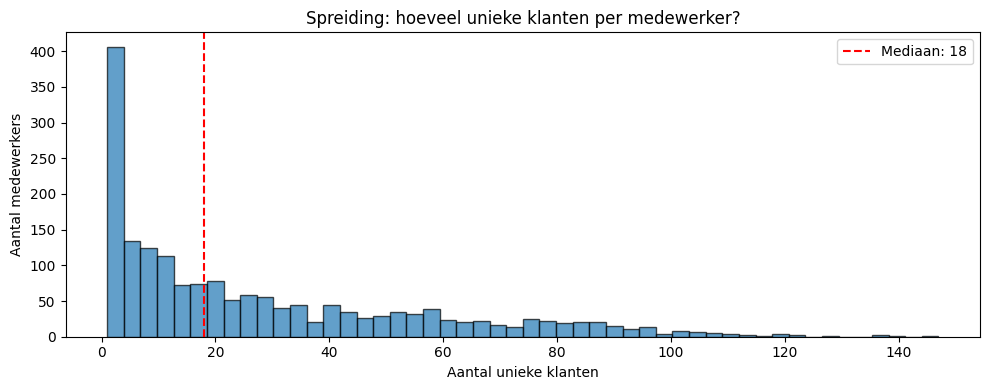

In [389]:
# Hoeveel unieke klanten heeft een gemiddelde medewerker?
klanten_per_med = (
    klant_bezoeken.groupby(["con", "URENVERANTW_MEDID"])["RELATIE_ID"]
    .nunique()
    .reset_index(name="unieke_klanten")
)

print("Unieke klanten per medewerker:")
print(klanten_per_med["unieke_klanten"].describe().round(1))

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(klanten_per_med["unieke_klanten"], bins=50, edgecolor="black", alpha=0.7)
ax.set_xlabel("Aantal unieke klanten")
ax.set_ylabel("Aantal medewerkers")
ax.set_title("Spreiding: hoeveel unieke klanten per medewerker?")
ax.axvline(
    klanten_per_med["unieke_klanten"].median(),
    color="red",
    ls="--",
    label=f"Mediaan: {klanten_per_med['unieke_klanten'].median():.0f}",
)
ax.legend()
plt.tight_layout()
plt.show()

Concentratie-index per medewerker (1.0 = altijd zelfde klant, ~0 = breed):
count    1795.000
mean        0.357
std         0.324
min         0.018
25%         0.109
50%         0.225
75%         0.500
max         1.000
Name: concentratie_index, dtype: float64


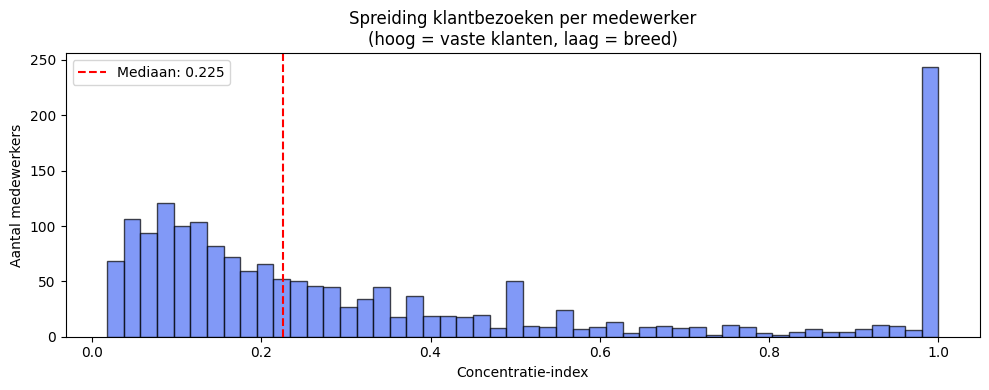


24.6% van de medewerkers gaat voornamelijk naar vaste klanten (index > 0.5)
→ Voldoende spreiding om klantvoorkeur te modelleren


In [390]:
# Concentratie: gaan medewerkers vaak naar dezelfde klanten of juist breed?
# Herfindahl-index: 1.0 = altijd dezelfde klant, ~0 = heel breed gespreid
def herfindahl(groep):
    aandelen = groep / groep.sum()
    return (aandelen**2).sum()


concentratie = (
    klant_bezoeken.groupby(["con", "URENVERANTW_MEDID"])["aantal_bezoeken"]
    .apply(herfindahl)
    .reset_index(name="concentratie_index")
)

print("Concentratie-index per medewerker (1.0 = altijd zelfde klant, ~0 = breed):")
print(concentratie["concentratie_index"].describe().round(3))

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(concentratie["concentratie_index"], bins=50, edgecolor="black", alpha=0.7, color="#4c6ef5")
ax.set_xlabel("Concentratie-index")
ax.set_ylabel("Aantal medewerkers")
ax.set_title("Spreiding klantbezoeken per medewerker\n(hoog = vaste klanten, laag = breed)")
ax.axvline(
    concentratie["concentratie_index"].median(),
    color="red",
    ls="--",
    label=f"Mediaan: {concentratie['concentratie_index'].median():.3f}",
)
ax.legend()
plt.tight_layout()
plt.show()

hoog = (concentratie["concentratie_index"] > 0.5).mean() * 100
print(f"\n{hoog:.1f}% van de medewerkers gaat voornamelijk naar vaste klanten (index > 0.5)")
print(f"→ {'Voldoende' if hoog > 20 else 'Beperkte'} spreiding om klantvoorkeur te modelleren")

### Machines & bewerkingen per medewerker

In [391]:
# Bewerkingen per medewerker — absolute frequentie
bewerking_freq = (
    df_model.groupby(["con", "URENVERANTW_MEDID", "DIENST_ART_ID"])
    .size()
    .reset_index(name="aantal_keer")
)

print(f"Totaal medewerker-bewerking combinaties: {len(bewerking_freq):,}")
print(f"Unieke bewerkingen in totaal: {bewerking_freq['DIENST_ART_ID'].nunique():,}")
bewerking_freq.sort_values("aantal_keer", ascending=False).head(10)

Totaal medewerker-bewerking combinaties: 26,172
Unieke bewerkingen in totaal: 1,240


,con,URENVERANTW_MEDID,DIENST_ART_ID,aantal_keer
18411,24_kuijpers,101,10002,1482
18476,24_kuijpers,329,10002,1458
24143,25_kuijpers,52,40031,1096
18338,24_kuijpers,38,10002,1050
8223,22_melse,125,521,935
24261,25_kuijpers,331,10013,924
18501,24_kuijpers,331,10013,864
24185,25_kuijpers,101,10002,844
18306,24_kuijpers,28,10003,831
24038,25_kuijpers,28,10002,752


Unieke bewerkingen per medewerker:
count    1795.0
mean       14.6
std        14.6
min         1.0
25%         3.0
50%        10.0
75%        22.0
max        90.0
Name: unieke_bewerkingen, dtype: float64


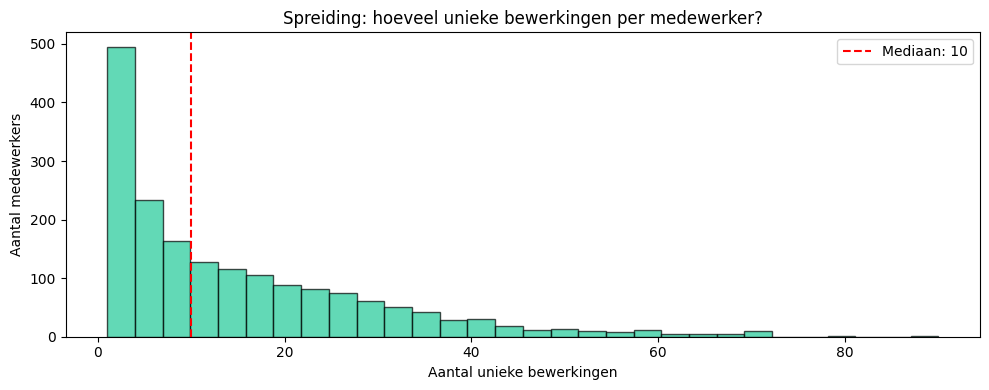

In [392]:
# Hoeveel unieke bewerkingen per medewerker?
bewerkingen_per_med = (
    bewerking_freq.groupby(["con", "URENVERANTW_MEDID"])["DIENST_ART_ID"]
    .nunique()
    .reset_index(name="unieke_bewerkingen")
)

print("Unieke bewerkingen per medewerker:")
print(bewerkingen_per_med["unieke_bewerkingen"].describe().round(1))

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(
    bewerkingen_per_med["unieke_bewerkingen"],
    bins=30,
    edgecolor="black",
    alpha=0.7,
    color="#20c997",
)
ax.set_xlabel("Aantal unieke bewerkingen")
ax.set_ylabel("Aantal medewerkers")
ax.set_title("Spreiding: hoeveel unieke bewerkingen per medewerker?")
ax.axvline(
    bewerkingen_per_med["unieke_bewerkingen"].median(),
    color="red",
    ls="--",
    label=f"Mediaan: {bewerkingen_per_med['unieke_bewerkingen'].median():.0f}",
)
ax.legend()
plt.tight_layout()
plt.show()

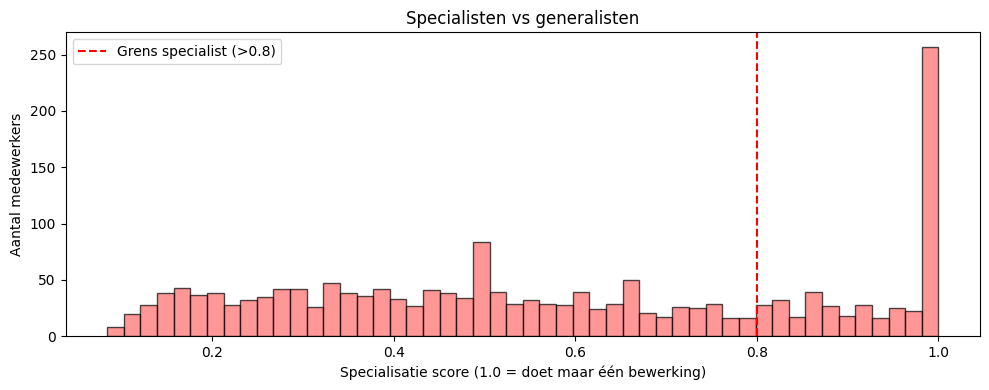

Specialisten (>80% op één bewerking): 27.9%
Generalisten (<40% op één bewerking): 32.4%


In [393]:
# Specialisatie vs generalisten
spec = (
    bewerking_freq.groupby(["con", "URENVERANTW_MEDID"])
    .apply(lambda g: g["aantal_keer"].max() / g["aantal_keer"].sum())
    .reset_index(name="specialisatie_score")
)

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(spec["specialisatie_score"], bins=50, edgecolor="black", alpha=0.7, color="#ff6b6b")
ax.set_xlabel("Specialisatie score (1.0 = doet maar één bewerking)")
ax.set_ylabel("Aantal medewerkers")
ax.set_title("Specialisten vs generalisten")
ax.axvline(0.8, color="red", ls="--", label="Grens specialist (>0.8)")
ax.legend()
plt.tight_layout()
plt.show()

specialisten = (spec["specialisatie_score"] > 0.8).mean() * 100
generalisten = (spec["specialisatie_score"] < 0.4).mean() * 100
print(f"Specialisten (>80% op één bewerking): {specialisten:.1f}%")
print(f"Generalisten (<40% op één bewerking): {generalisten:.1f}%")

### Gecombineerd medewerker profiel

In [394]:
# Bouw een volledig profiel per medewerker samen
medewerker_profiel = (
    klanten_per_med.merge(bewerkingen_per_med, on=["con", "URENVERANTW_MEDID"])
    .merge(concentratie, on=["con", "URENVERANTW_MEDID"])
    .merge(spec, on=["con", "URENVERANTW_MEDID"])
)

totaal = df_model.groupby(["con", "URENVERANTW_MEDID"]).size().reset_index(name="totaal_opdrachten")
medewerker_profiel = medewerker_profiel.merge(totaal, on=["con", "URENVERANTW_MEDID"])

print(f"Profielen gebouwd voor {len(medewerker_profiel):,} medewerkers")
print("\nTop 10 medewerkers op aantal opdrachten:")
print(
    medewerker_profiel.sort_values("totaal_opdrachten", ascending=False)
    .head(10)
    .to_string(index=False)
)

Profielen gebouwd voor 1,795 medewerkers

Top 10 medewerkers op aantal opdrachten:
        con  URENVERANTW_MEDID  unieke_klanten  unieke_bewerkingen  concentratie_index  specialisatie_score  totaal_opdrachten
24_kuijpers                101              57                  18            0.047946             0.951830               1557
24_kuijpers                329              53                   9            0.052928             0.974599               1496
25_kuijpers                 52              93                  28            0.341886             0.766434               1430
25_kuijpers                331              74                  30            0.090308             0.728707               1268
24_kuijpers                331              73                  26            0.050199             0.757895               1140
24_kuijpers                 15              86                  36            0.170027             0.365611               1105
24_kuijpers                 

In [395]:
# Analyse: is er voldoende spreiding voor zinvolle profielen?
print("=" * 60)
print("CONCLUSIE: SPREIDING VOOR RESOURCE-MATCHING PROFIELEN")
print("=" * 60)

min_opdrachten = 20
bruikbaar = (medewerker_profiel["totaal_opdrachten"] >= min_opdrachten).sum()
totaal_med = len(medewerker_profiel)

print(f"\nTotaal medewerkers:           {totaal_med:,}")
print(
    f"Bruikbaar (≥{min_opdrachten} opdrachten):  {bruikbaar:,} ({bruikbaar / totaal_med * 100:.1f}%)"
)
print(f"\nGemiddeld unieke klanten:     {medewerker_profiel['unieke_klanten'].mean():.1f}")
print(f"Gemiddeld unieke bewerkingen: {medewerker_profiel['unieke_bewerkingen'].mean():.1f}")
print(
    f"\nSpecialisten (>80%):          {(medewerker_profiel['specialisatie_score'] > 0.8).sum():,}"
)
print(f"Generalisten (<40%):           {(medewerker_profiel['specialisatie_score'] < 0.4).sum():,}")

voldoende = bruikbaar / totaal_med > 0.6
print(f"\n→ Spreiding {'voldoende' if voldoende else 'beperkt'} voor resource-matching profielen")
print("→ Nieuwe modelfeatures toegevoegd aan df_model:")
print("   - med_klant_bezoeken    (hoe vaak bij deze klant geweest)")
print("   - med_klant_ratio       (voorkeur indicator)")
print("   - med_klant_snelheid    (snelheid bij deze klant)")
print("   - med_bewerking_snelheid (snelheid bij dit bewerkingstype)")

CONCLUSIE: SPREIDING VOOR RESOURCE-MATCHING PROFIELEN

Totaal medewerkers:           1,795
Bruikbaar (≥20 opdrachten):  1,352 (75.3%)

Gemiddeld unieke klanten:     27.9
Gemiddeld unieke bewerkingen: 14.6

Specialisten (>80%):          500
Generalisten (<40%):           582

→ Spreiding voldoende voor resource-matching profielen
→ Nieuwe modelfeatures toegevoegd aan df_model:
   - med_klant_bezoeken    (hoe vaak bij deze klant geweest)
   - med_klant_ratio       (voorkeur indicator)
   - med_klant_snelheid    (snelheid bij deze klant)
   - med_bewerking_snelheid (snelheid bij dit bewerkingstype)


In [396]:
df_model.groupby("EENHEID_OMS").count()

,URENVERANTW_ID,URENVERANTW_DATUM,URENVERANTW_PROJID,URENVERANTW_RELATIEID,URENVERANTW_TIJDSOORT,URENVERANTW_AANTAL,URENVERANTW_MACHID,URENVERANTW_MEDID,URENVERANTW_ORDERID,URENVERANTW_ORDDAID,...,oms_vec_7,oms_vec_8,oms_vec_9,med_klant_bezoeken,med_totaal_opdrachten,med_klant_ratio,med_klant_gem_tijd,med_klant_snelheid,med_bewerking_gem_tijd,med_bewerking_snelheid
EENHEID_OMS,,,,,,,,,,,,,,,,,,,,,
M3,140,140,0,140,140,140,0,140,140,140,...,140,140,140,140,140,140,140,140,140,140
Hdag,1,1,1,1,1,1,0,1,1,1,...,1,1,1,1,1,1,1,1,1,1
are,1,1,0,1,1,1,0,1,1,1,...,1,1,1,1,1,1,1,1,1,1
baal,2054,2054,86,2052,2054,2054,0,2054,2054,2054,...,2054,2054,2054,2054,2054,2054,2054,2054,2030,2054
dag,219,219,20,219,219,219,0,219,219,219,...,219,219,219,219,219,219,219,219,175,219
dagen,6,6,0,6,6,6,0,6,6,6,...,6,6,6,6,6,6,6,6,6,6
gram,1,1,0,1,1,1,0,1,1,1,...,1,1,1,1,1,1,1,1,1,1
ha,1251,1251,54,1251,1251,1251,0,1251,1251,1251,...,1251,1251,1251,1251,1251,1251,1251,1251,1248,1251
ha.,12815,12815,871,12630,12815,12815,0,12815,12815,12815,...,12815,12815,12815,12815,12815,12815,12815,12815,12813,12815


In [397]:
ha_eenheden = ["ha", "ha."]
volume_eenheden = ["m3", "m3.", "ltr", "ltr."]
gewicht_eenheden = ["ton", "kg"]
stuks_eenheden = ["stuk", "st.", "st", "pak", "baal", "rol", "keer", "kr."]

df_model["hoeveelheid_ha"] = df_model["ORDRG_HOEVEELHEID"].where(
    df_model["EENHEID_OMS"].isin(ha_eenheden)
)
df_model["hoeveelheid_volume"] = df_model["ORDRG_HOEVEELHEID"].where(
    df_model["EENHEID_OMS"].isin(volume_eenheden)
)
df_model["hoeveelheid_gewicht"] = df_model["ORDRG_HOEVEELHEID"].where(
    df_model["EENHEID_OMS"].isin(gewicht_eenheden)
)
df_model["hoeveelheid_stuks"] = df_model["ORDRG_HOEVEELHEID"].where(
    df_model["EENHEID_OMS"].isin(stuks_eenheden)
)

In [398]:
df_model["hoeveelheid_aanwezig"] = (
    ~df_model["hoeveelheid_ha"].isna()
    | ~df_model["hoeveelheid_volume"].isna()
    | ~df_model["hoeveelheid_gewicht"].isna()
    | ~df_model["hoeveelheid_stuks"].isna()
).astype(int)

In [399]:
counts = df_model["con"].value_counts()
df_model = df_model[df_model["con"].isin(counts[counts >= 1000].index)]

In [400]:
df_model["week_sin"] = np.sin(2 * np.pi * df_model["URENVERANTW_WEEKNR"].astype(float) / 52)
df_model["week_cos"] = np.cos(2 * np.pi * df_model["URENVERANTW_WEEKNR"].astype(float) / 52)
df_model["dag_sin"] = np.sin(2 * np.pi * df_model["dag_van_week"].astype(float) / 7)
df_model["dag_cos"] = np.cos(2 * np.pi * df_model["dag_van_week"].astype(float) / 7)
df_model["maand_sin"] = np.sin(2 * np.pi * df_model["maand"].astype(float) / 12)
df_model["maand_cos"] = np.cos(2 * np.pi * df_model["maand"].astype(float) / 12)

In [401]:
df = df_model[df_model["hoeveelheid_aanwezig"] == 1]

In [402]:
print(len(df) / len(df_model) * 100)

8.706686281627531


In [403]:
df_model.to_csv("werkexpert.csv", index=False)

In [404]:
df_model.head()

,URENVERANTW_ID,URENVERANTW_DATUM,URENVERANTW_PROJID,URENVERANTW_RELATIEID,URENVERANTW_TIJDSOORT,URENVERANTW_AANTAL,URENVERANTW_MACHID,URENVERANTW_MEDID,URENVERANTW_ORDERID,URENVERANTW_ORDDAID,...,hoeveelheid_volume,hoeveelheid_gewicht,hoeveelheid_stuks,hoeveelheid_aanwezig,week_sin,week_cos,dag_sin,dag_cos,maand_sin,maand_cos
17,1279962,2015-01-16,NaN,4144.0,3,9.0,NaN,25,74240.0,188465.0,...,NaN,NaN,NaN,0,0.354605,0.935016,-0.433884,-0.900969,0.5,0.866025
14,1287684,2015-01-16,2940.0,4266.0,3,9.0,NaN,753,74171.0,188247.0,...,NaN,NaN,NaN,0,0.354605,0.935016,-0.433884,-0.900969,0.5,0.866025
15,1279944,2015-01-16,NaN,4144.0,3,9.0,NaN,25,74240.0,188464.0,...,NaN,NaN,0.0,1,0.354605,0.935016,-0.433884,-0.900969,0.5,0.866025
16,1278776,2015-01-16,2940.0,4266.0,3,9.0,NaN,32,74208.0,188370.0,...,NaN,NaN,NaN,0,0.354605,0.935016,-0.433884,-0.900969,0.5,0.866025
19,1287702,2015-01-17,2940.0,4266.0,3,6.5,NaN,753,74171.0,188248.0,...,NaN,NaN,NaN,0,0.354605,0.935016,-0.974928,-0.222521,0.5,0.866025


In [405]:
df_model.columns.to_series().to_csv("werkexpert_columns.csv", index=False)